# Inbound Transcript Analysis

This notebook documents the process of joining Extension data to the inbound call transcript extractions, and provides a foundation for further analysis.

## 1. Data Sources

**Source Files:**
- `combined_extractions_inbound.csv` - Extracted features from inbound call transcripts (3,918 rows)
- `Recordings 12-15-2025 _ 1-13-2026.csv` - Call recordings metadata with Extension info (9,423 rows)

**Goal:** Add the `Extension` column (Hertz branch/location identifier) to the transcript extractions.

In [428]:
import pandas as pd
import re

# Load the data
extractions = pd.read_csv('../data/audio 2/JSON_Inbound/combined_extractions_inbound.csv')
recordings = pd.read_csv('../data/audio 2/JSON_Inbound/Recordings 12-15-2025 _ 1-13-2026.csv', dtype={'Call ID': str})

print(f"Extractions: {len(extractions)} rows, {len(extractions.columns)} columns")
print(f"Recordings: {len(recordings)} rows, {len(recordings.columns)} columns")

Extractions: 3915 rows, 69 columns
Recordings: 9423 rows, 12 columns


## 2. Understanding the Source File Format

The `source_file` column in extractions contains structured information about each call:

```
in-{DID}-{CALLER_PHONE}-{DATE}-{TIME}-{CALL_ID}_extracted
```

| Component | Example | Description |
|-----------|---------|-------------|
| `in` | in | Direction (inbound) |
| DID | +16152752600 | Hertz location phone (Direct Inward Dial) |
| CALLER_PHONE | +12177662392 | Customer's phone number |
| DATE | 20260107 | Call date (YYYYMMDD) |
| TIME | 171557 | Call time (HHMMSS) |
| CALL_ID | 1767824157.622990 | Unique call identifier |

**Key Discovery:** The first phone number is the DID (Hertz location), not the caller's phone. This maps directly to the Extension.

In [429]:
# Parse source_file to show components
sample = extractions['source_file'].iloc[46]  # A row with Extension
print(f"Example source_file:\n{sample}\n")

# Parse it
match = re.match(r'in-(\+\d+)-(\+\d+)-(\d{8})-(\d{6})-(\d+\.\d+)', sample)
if match:
    print("Parsed components:")
    print(f"  DID (Hertz):     {match.group(1)}")
    print(f"  Caller Phone:   {match.group(2)}")
    print(f"  Date:           {match.group(3)}")
    print(f"  Time:           {match.group(4)}")
    print(f"  Call ID:        {match.group(5)}")

Example source_file:
in-+12253575992-+12177662392-20260106-191853-1767745133.276644 (1)_extracted

Parsed components:
  DID (Hertz):     +12253575992
  Caller Phone:   +12177662392
  Date:           20260106
  Time:           191853
  Call ID:        1767745133.276644


## 3. JOIN Strategy

### Initial Attempts (Lower Match Rates)

| Strategy | Match Rate | Issue |
|----------|------------|-------|
| Exact Call ID | 50.4% | Different decimal portions |
| Call ID Prefix | 50.9% | Only partial overlap |
| Phone + Date | 0% | Misidentified phone fields |

### Final Solution: DID Matching (83.3%)

The DID (first phone in source_file) maps directly to the Extension in recordings:
- Extract DID from `source_file` 
- Normalize `DID` column in recordings to same format
- Join on DID to get Extension

In [430]:
# Show the DID -> Extension mapping from recordings
def normalize_phone(phone):
    if pd.isna(phone):
        return None
    digits = re.sub(r'\D', '', str(phone))
    if len(digits) == 10:
        return f'+1{digits}'
    elif len(digits) == 11 and digits.startswith('1'):
        return f'+{digits}'
    return f'+{digits}'

recordings['did_normalized'] = recordings['DID'].apply(normalize_phone)

# DID to Extension mapping
did_extension_map = recordings.drop_duplicates(subset=['did_normalized'])[['did_normalized', 'Extension', 'Description']]
print(f"Unique DID -> Extension mappings: {len(did_extension_map)}")
did_extension_map.head(10)

Unique DID -> Extension mappings: 54


,did_normalized,Extension,Description
0,+14124651048,55966 (Pittsburg Intl AP 1885-11 Mgr VM),Pittsburg Intl AP 1885-11
6,+14708098308,43026 (Atlanta TNC 5101-01 Main Line),Atlanta TNC 5101-01
7,+16822890383,43334 (TNC BEDFORD 4665-20 Extension 1),ECID-TNC BEDFORD 4665-20
10,+18594791341,35958 (Cincinnati INT AP HLE 1542-11 Sick Line),cincinnatiap154211_ap_sickline
12,+16152752600,50013 (Nashville AP 1486-11 Counter 1),Five9 Nashville AP 148611
30,+13674065893,61086 (Brossard CAN HLE 8086-02),TR-8086-02-Brossard CAN HLE
34,+12253575992,35393 (Baton Rouge AP 1445-20),Five9 Baton Rouge AP 1445-20
35,+14704920218,60867 (Canton HLE 5601-05 Extension 1),IVR TR_5601-05-HLE Canton GA 560105
46,+19049156012,43347 (Southside HLE Kia 7449-25 Extension 2),IVR Southside HLE Kia 7449-25
53,+19852413412,32114 (Covington HLE 4940-07 Extension 4),IVR-Five9-Covington HLE 4940-07


In [431]:
# The JOIN code (already applied to the file)
def extract_did(sf):
    match = re.match(r'in-(\+\d+)-', sf)
    return match.group(1) if match else None

# Extract DID from source_file
extractions['did'] = extractions['source_file'].apply(extract_did)

# Check match rate
matched = extractions['did'].isin(did_extension_map['did_normalized']).sum()
print(f"Match rate: {matched} / {len(extractions)} ({matched/len(extractions)*100:.1f}%)")

Match rate: 3261 / 3915 (83.3%)


## 4. Results Summary

The Extension column has been successfully added to `combined_extractions_inbound.csv`:

| Metric | Value |
|--------|-------|
| Total rows | 3,918 |
| Rows with Extension | 3,264 (83.3%) |
| Rows without Extension | 654 (16.7%) |
| Unique Extensions matched | 43 |

The 654 unmatched rows have DIDs that don't appear in the recordings file (different Hertz locations not covered in that dataset).

In [432]:
# Verify the JOIN results
print("Extension column stats:")
print(f"  With Extension: {extractions['Extension'].notna().sum()}")
print(f"  Without Extension: {extractions['Extension'].isna().sum()}")

print(f"\nTop Extensions by call count:")
extractions['Extension'].value_counts().head(10)

Extension column stats:
  With Extension: 3261
  Without Extension: 654

Top Extensions by call count:


Extension
50013 (Nashville AP 1486-11 Counter 1)          1166
55966 (Pittsburg Intl AP 1885-11 Mgr VM)         821
35393 (Baton Rouge AP 1445-20)                   220
33524 (Katy Freeway HLE 7663-35 Extension 4)     154
43376 (Springfield Amtrak  HLE 7771-06)          153
42947 (Aventura HLE  7414-02 Extension 2)         94
61086 (Brossard CAN HLE 8086-02)                  92
43737 (Marriott Downtown Waterfront 7310-08)      77
61114 (Brampton HLE CAN 8176-04(61115))           75
43334 (TNC BEDFORD 4665-20 Extension 1)           64
Name: count, dtype: int64

## Verification: Call ID vs DID JOIN Equivalence

This cell verifies that when both JOIN methods match, they produce the same Extension.

In [433]:
# ============================================
# VERIFICATION: Call ID vs DID JOIN Equivalence
# ============================================

import pandas as pd
import re

# Load fresh copies
extractions = pd.read_csv('../data/audio 2/JSON_Inbound/combined_extractions_inbound.csv')
recordings = pd.read_csv('../data/audio 2/JSON_Inbound/Recordings 12-15-2025 _ 1-13-2026.csv', dtype={'Call ID': str})

# --- Extract both Call ID and DID from source_file ---
def parse_source_file(sf):
    """Extract DID and Call ID from source filename"""
    match = re.match(r'in-(\+\d+)-\+\d+-\d{8}-\d{6}-(\d+\.\d+)', sf)
    if match:
        return pd.Series({'did_extracted': match.group(1), 'call_id_extracted': match.group(2)})
    return pd.Series({'did_extracted': None, 'call_id_extracted': None})

extractions[['did_extracted', 'call_id_extracted']] = extractions['source_file'].apply(parse_source_file)

# --- Normalize DID in recordings ---
def normalize_phone(phone):
    if pd.isna(phone):
        return None
    digits = re.sub(r'\D', '', str(phone))
    if len(digits) == 10:
        return f'+1{digits}'
    elif len(digits) == 11 and digits.startswith('1'):
        return f'+{digits}'
    return f'+{digits}'

recordings['did_normalized'] = recordings['DID'].apply(normalize_phone)

# --- Method 1: JOIN via Call ID ---
# Use the integer portion of Call ID for matching (as noted, decimal portions differ)
extractions['call_id_prefix'] = extractions['call_id_extracted'].apply(
    lambda x: x.split('.')[0] if pd.notna(x) else None
)
recordings['call_id_prefix'] = recordings['Call ID'].apply(
    lambda x: str(x).split('.')[0] if pd.notna(x) else None
)

# Create Call ID -> Extension mapping
call_id_ext_map = recordings.drop_duplicates(subset=['call_id_prefix'])[['call_id_prefix', 'Extension']].copy()
call_id_ext_map = call_id_ext_map.rename(columns={'Extension': 'Extension_via_CallID'})

# --- Method 2: JOIN via DID ---
did_ext_map = recordings.drop_duplicates(subset=['did_normalized'])[['did_normalized', 'Extension']].copy()
did_ext_map = did_ext_map.rename(columns={'Extension': 'Extension_via_DID'})

# --- Apply both JOINs ---
merged = extractions.merge(call_id_ext_map, on='call_id_prefix', how='left')
merged = merged.merge(did_ext_map, left_on='did_extracted', right_on='did_normalized', how='left')

# --- Compare results ---
both_matched = merged[
    (merged['Extension_via_CallID'].notna()) & 
    (merged['Extension_via_DID'].notna())
].copy()

print(f"Total extractions: {len(extractions):,}")
print(f"Matched via Call ID only: {merged['Extension_via_CallID'].notna().sum():,}")
print(f"Matched via DID only: {merged['Extension_via_DID'].notna().sum():,}")
print(f"Matched via BOTH methods: {len(both_matched):,}")
print()

# Check for discrepancies
both_matched['extensions_match'] = both_matched['Extension_via_CallID'] == both_matched['Extension_via_DID']
discrepancies = both_matched[~both_matched['extensions_match']]

print(f"Rows where both methods matched: {len(both_matched):,}")
print(f"Rows where Extensions AGREE: {both_matched['extensions_match'].sum():,}")
print(f"Rows where Extensions DISAGREE: {len(discrepancies):,}")
print()

if len(discrepancies) == 0:
    print("✅ VERIFIED: When both JOINs match, they produce IDENTICAL Extensions.")
    print("   The JOINs are equivalent - DID method just has higher match rate.")
else:
    print(f"⚠️ WARNING: {len(discrepancies)} rows have different Extensions!")
    print("\nSample discrepancies:")
    print(discrepancies[['source_file', 'Extension_via_CallID', 'Extension_via_DID']].head(10))

Total extractions: 3,915
Matched via Call ID only: 1,999
Matched via DID only: 3,251
Matched via BOTH methods: 1,995

Rows where both methods matched: 1,995
Rows where Extensions AGREE: 1,440
Rows where Extensions DISAGREE: 555

⚠️ WARNING: 555 rows have different Extensions!

Sample discrepancies:
                                           source_file  \
50   in-+12253575992-+12252881421-20260106-200444-1...   
51   in-+12253575992-+12252881421-20260106-200444-1...   
62   in-+12253575992-+12253620809-20260105-214544-1...   
63   in-+12253575992-+12253620809-20260105-214544-1...   
131  in-+12253575992-+12252735464-20260107-092225-1...   
133  in-+12253575992-+12253011307-20260109-205634-1...   
161  in-+12253575992-+12256508355-20260110-143023-1...   
164  in-+12253575992-+12259163287-20260105-173029-1...   
174  in-+12253575992-+12282820403-20260109-171238-1...   
186  in-+12253575992-+14407248405-20260105-122518-1...   

                        Extension_via_CallID               Ex

## 5. Data Overview

Now let's explore the combined dataset with Extension information.

In [434]:
# Reload the final dataset
df = pd.read_csv('../data/audio 2/JSON_Inbound/combined_extractions_inbound.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn groups:")
print(f"  - source_file, Extension")
print(f"  - extraction_status")
print(f"  - A_call_answer_status.*")
print(f"  - B_identity_routing.*")
print(f"  - C_intent.*")
print(f"  - D_issue_diagnostics.*")
print(f"  - E_change_requests.*")
print(f"  - F_pickup_delivery.*")
print(f"  - G_transfers_escalations.*")
print(f"  - H_outcome.*")
print(f"  - I_complaints.*")
print(f"  - J_hold_experience.*")

Dataset shape: (3915, 69)

Column groups:
  - source_file, Extension
  - extraction_status
  - A_call_answer_status.*
  - B_identity_routing.*
  - C_intent.*
  - D_issue_diagnostics.*
  - E_change_requests.*
  - F_pickup_delivery.*
  - G_transfers_escalations.*
  - H_outcome.*
  - I_complaints.*
  - J_hold_experience.*


In [435]:
# Quick look at call outcomes by Extension
df_matched = df[df['Extension'].notna()].copy()

print("Call Answer Status distribution (using refined classification):")
df_matched['call_status_refined'].value_counts()

Call Answer Status distribution (using refined classification):


call_status_refined
stuck_in_call_tree    2386
answered_by_human      778
not_answered            80
answered_by_va          17
Name: count, dtype: int64

In [436]:
# Call outcomes by Extension (top 10)
outcome_by_ext = df_matched.groupby('Extension')['H_outcome.call_outcome'].value_counts().unstack(fill_value=0)
outcome_by_ext['total'] = outcome_by_ext.sum(axis=1)
outcome_by_ext = outcome_by_ext.sort_values('total', ascending=False).head(10)
outcome_by_ext

H_outcome.call_outcome,canceled_or_abandoned,not_resolved,partially_resolved_needs_followup,resolved_and_ready,resolved_but_pending_branch_or_inventory,total
Extension,,,,,,
33524 (Katy Freeway HLE 7663-35 Extension 4),1,39,53,31,12,136
55966 (Pittsburg Intl AP 1885-11 Mgr VM),36,73,4,1,1,115
35393 (Baton Rouge AP 1445-20),0,35,36,26,10,107
50013 (Nashville AP 1486-11 Counter 1),22,72,6,2,1,103
61086 (Brossard CAN HLE 8086-02),1,16,33,24,15,89
61114 (Brampton HLE CAN 8176-04(61115)),3,26,16,12,8,65
43334 (TNC BEDFORD 4665-20 Extension 1),1,17,32,6,6,62
60738 (Calgary South Pointe Toyota HLE 8143-03),2,12,9,17,20,60
43376 (Springfield Amtrak HLE 7771-06),4,23,15,6,5,53


---

# Part 2: Inbound Call Analysis

## 1. How We Got to This Sample

**Data Pipeline:**

| Step | Description | Volume |
|------|-------------|--------|
| 1. Source Data | Call recordings metadata from VanRan | ~9,400 calls (Dec 15, 2025 - Jan 13, 2026) |
| 2. Downloaded Audio | Subset of recordings with audio files | 1 Jan - 13 Jan 2026 |
| 3. Transcribed & Extracted | Unique calls with transcript extractions | **~3,900 calls** (after deduplication) |

**Note on Branch-Level Data:**
- We attempted to join branch/Extension data but the DID-to-Extension mapping is incomplete
- Until VanRan provides per-call Extension details, branch-level analysis is limited
- Current analysis focuses on **call-level patterns** independent of branch

In [437]:
# ============================================
# 2. HIGH-LEVEL CALL OVERVIEW
# ============================================
import re
import numpy as np

# Function to extract call duration from transcript
def get_call_duration(transcript):
    """Extract call duration in seconds from transcript timestamps [start - end]"""
    if pd.isna(transcript):
        return None
    matches = re.findall(r'\[[\d.]+ - ([\d.]+)\]', str(transcript))
    if matches:
        return float(matches[-1])  # Last timestamp is call duration
    return None

# Add call duration column
df['call_duration_sec'] = df['Transcript'].apply(get_call_duration)

# Categorize call duration
def categorize_duration(seconds):
    if pd.isna(seconds):
        return 'Unknown'
    elif seconds <= 30:
        return '0-30 sec'
    elif seconds <= 60:
        return '30-60 sec'
    elif seconds <= 120:
        return '1-2 min'
    elif seconds <= 300:
        return '2-5 min'
    else:
        return '5+ min'

df['duration_category'] = df['call_duration_sec'].apply(categorize_duration)

# Calculate main status breakdown
call_status = df['call_status_refined'].value_counts()
total = len(df)

answered_human = call_status.get('answered_by_human', 0)
answered_va = call_status.get('answered_by_va', 0)
stuck = call_status.get('stuck_in_call_tree', 0)
not_answered = call_status.get('not_answered', 0)

print(f"Total calls analyzed: {total:,}")
print(f"  - Answered by Human: {answered_human:,} ({answered_human/total*100:.1f}%)")
print(f"  - Answered by Hailey (VA): {answered_va:,} ({answered_va/total*100:.1f}%)")
print(f"  - Stuck in Call Tree: {stuck:,} ({stuck/total*100:.1f}%)")
print(f"  - Not Answered: {not_answered:,} ({not_answered/total*100:.1f}%)")

Total calls analyzed: 3,915
  - Answered by Human: 903 (23.1%)
  - Answered by Hailey (VA): 157 (4.0%)
  - Stuck in Call Tree: 2,670 (68.2%)
  - Not Answered: 185 (4.7%)


/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/4073417615.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


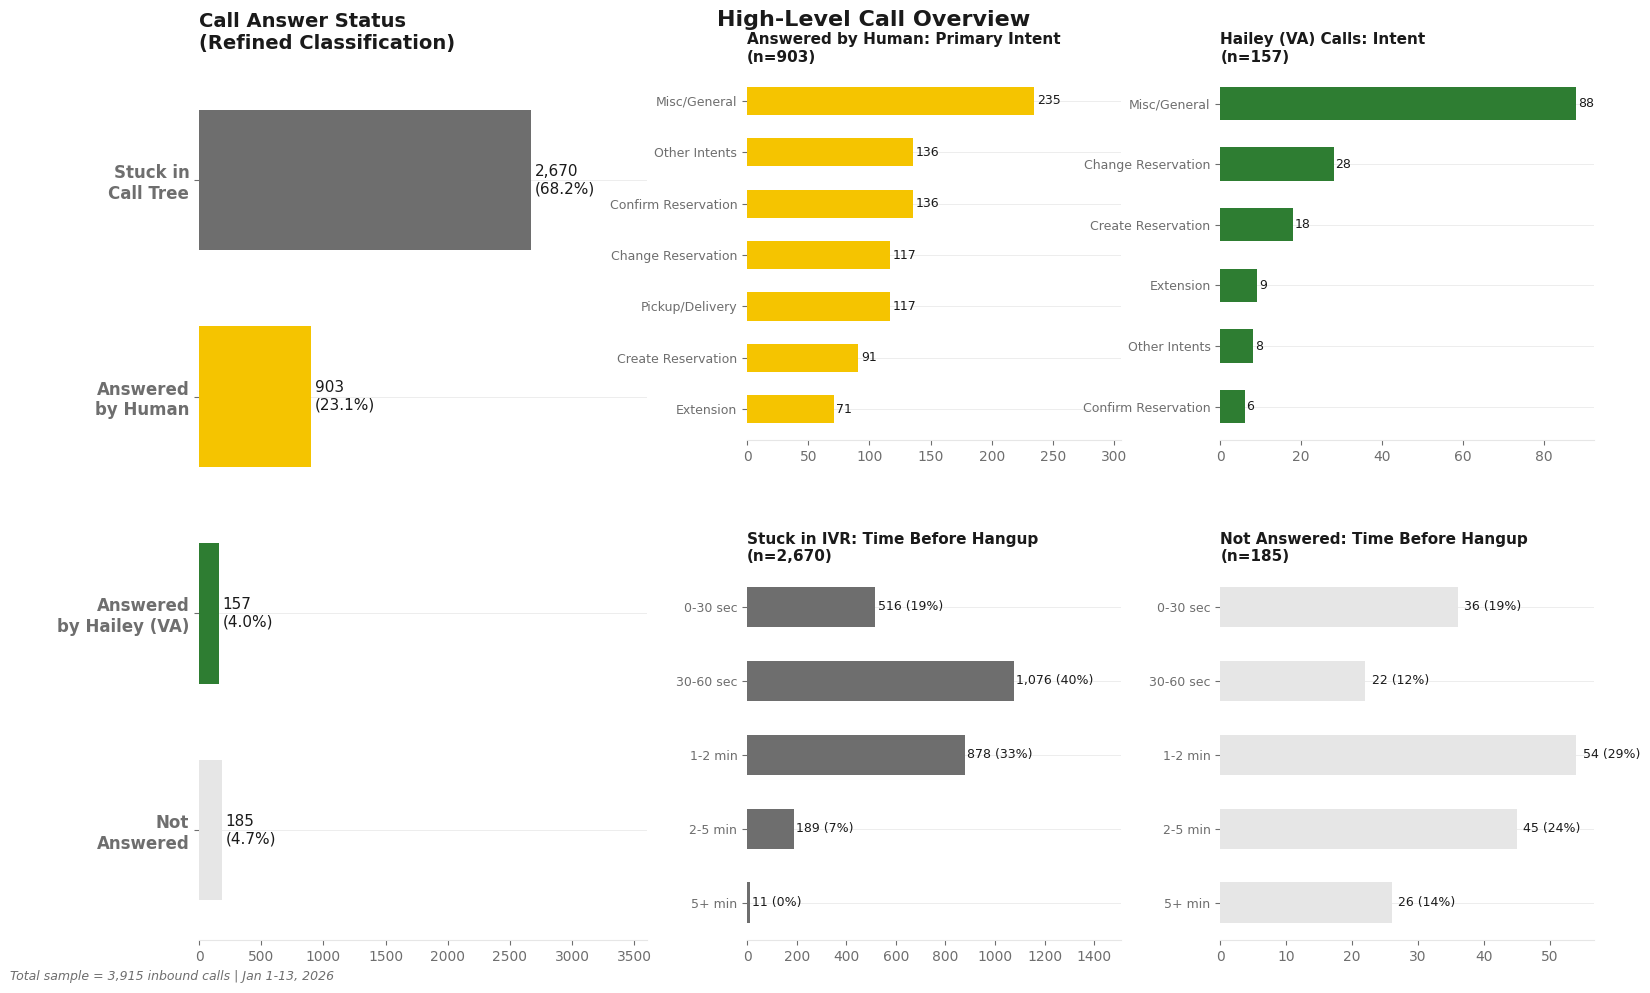

In [438]:
# ============================================
# HIGH-LEVEL OVERVIEW VISUALIZATION
# LHS: Call status breakdown | RHS: Deeper breakdowns per category
# ============================================

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.25)

# Intent label mapping (consistent with Section 2.1)
intent_label_map = {
    'other': 'Misc/General',
    'change_reservation': 'Change Reservation',
    'confirm_reservation': 'Confirm Reservation',
    'pickup_delivery_coordination': 'Pickup/Delivery',
    'create_reservation': 'Create Reservation',
    'extension': 'Extension',
    'repair_issue': 'Repair Issue',
    'payment_deposit': 'Payment/Deposit',
    'other_intents': 'Other Intents'
}

# ========== LEFT SIDE: Main Call Status Breakdown ==========
ax_main = fig.add_subplot(gs[:, 0])

# Reordered: Stuck in Call Tree first
categories = ['Stuck in\nCall Tree', 'Answered\nby Human', 'Answered\nby Hailey (VA)', 'Not\nAnswered']
values = [stuck, answered_human, answered_va, not_answered]
colors = [DARK_GRAY, HERTZ_YELLOW, POSITIVE_GREEN, LIGHT_GRAY]

y_pos = np.arange(len(categories))
bars = ax_main.barh(y_pos, values, color=colors, height=0.65, edgecolor='none')

for bar, val in zip(bars, values):
    pct = val / total * 100
    ax_main.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, 
                f'{val:,}\n({pct:.1f}%)', va='center', ha='left', fontsize=11, color=CHARCOAL)

ax_main.set_yticks(y_pos)
ax_main.set_yticklabels(categories, fontsize=12, fontweight='bold')
ax_main.set_xlim(0, max(values) * 1.35)
ax_main.invert_yaxis()
style_axis(ax_main)
ax_main.set_title('Call Answer Status\n(Refined Classification)', fontsize=14, fontweight='bold', 
                  color=CHARCOAL, loc='left', pad=15)

# ========== RIGHT TOP: Answered by Human - Primary Intent ==========
ax_intent = fig.add_subplot(gs[0, 1])

df_answered_human_chart = df[df['call_status_refined'] == 'answered_by_human'].copy()

# Get top 5 specific intents (excluding 'other'), then add 'other' as Misc/General and group rest
raw_intent_counts = df_answered_human_chart['C_intent.primary_intent'].value_counts()
top_specific_intents = [i for i in raw_intent_counts.index if i != 'other'][:5]

# Create grouped intent column
def group_intent(x):
    if x == 'other':
        return 'Misc/General'
    elif x in top_specific_intents:
        return intent_label_map.get(x, x.replace('_', ' ').title())
    else:
        return 'Other Intents'

intent_grouped = df_answered_human_chart['C_intent.primary_intent'].apply(group_intent).value_counts()

y_pos = np.arange(len(intent_grouped))
bars = ax_intent.barh(y_pos, intent_grouped.values, color=HERTZ_YELLOW, height=0.55, edgecolor='none')

for bar, val in zip(bars, intent_grouped.values):
    ax_intent.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                  f'{val:,}', va='center', fontsize=9, color=CHARCOAL)

ax_intent.set_yticks(y_pos)
ax_intent.set_yticklabels(intent_grouped.index, fontsize=9)
ax_intent.set_xlim(0, intent_grouped.values[0] * 1.3)
ax_intent.invert_yaxis()
style_axis(ax_intent)
ax_intent.set_title(f'Answered by Human: Primary Intent\n(n={len(df_answered_human_chart):,})', 
                    fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== RIGHT TOP 2: Answered by VA - Primary Intent ==========
ax_va = fig.add_subplot(gs[0, 2])

df_va = df[df['call_status_refined'] == 'answered_by_va'].copy()

# Same grouping logic for VA calls
raw_va_intent_counts = df_va['C_intent.primary_intent'].value_counts()
top_va_specific_intents = [i for i in raw_va_intent_counts.index if i != 'other'][:4]

def group_va_intent(x):
    if x == 'other':
        return 'Misc/General'
    elif x in top_va_specific_intents:
        return intent_label_map.get(x, x.replace('_', ' ').title())
    else:
        return 'Other Intents'

va_intent_grouped = df_va['C_intent.primary_intent'].apply(group_va_intent).value_counts()

y_pos = np.arange(len(va_intent_grouped))
bars = ax_va.barh(y_pos, va_intent_grouped.values, color=POSITIVE_GREEN, height=0.55, edgecolor='none')

for bar, val in zip(bars, va_intent_grouped.values):
    ax_va.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
              f'{val:,}', va='center', fontsize=9, color=CHARCOAL)

ax_va.set_yticks(y_pos)
ax_va.set_yticklabels(va_intent_grouped.index, fontsize=9)
ax_va.invert_yaxis()
style_axis(ax_va)
ax_va.set_title(f'Hailey (VA) Calls: Intent\n(n={len(df_va):,})', 
                fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== BOTTOM LEFT: Stuck in Call Tree - Duration ==========
ax_stuck = fig.add_subplot(gs[1, 1])

df_stuck = df[df['call_status_refined'] == 'stuck_in_call_tree'].copy()
stuck_duration = df_stuck['duration_category'].value_counts()
# Reorder by duration
duration_order = ['0-30 sec', '30-60 sec', '1-2 min', '2-5 min', '5+ min', 'Unknown']
stuck_duration = stuck_duration.reindex([d for d in duration_order if d in stuck_duration.index])

y_pos = np.arange(len(stuck_duration))
bars = ax_stuck.barh(y_pos, stuck_duration.values, color=DARK_GRAY, height=0.55, edgecolor='none')

for bar, val in zip(bars, stuck_duration.values):
    pct = val / len(df_stuck) * 100
    ax_stuck.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                 f'{val:,} ({pct:.0f}%)', va='center', fontsize=9, color=CHARCOAL)

ax_stuck.set_yticks(y_pos)
ax_stuck.set_yticklabels(stuck_duration.index, fontsize=9)
ax_stuck.set_xlim(0, stuck_duration.values.max() * 1.4)
ax_stuck.invert_yaxis()
style_axis(ax_stuck)
ax_stuck.set_title(f'Stuck in IVR: Time Before Hangup\n(n={len(df_stuck):,})', 
                   fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== BOTTOM RIGHT: Not Answered - Duration ==========
ax_na = fig.add_subplot(gs[1, 2])

df_na = df[df['call_status_refined'] == 'not_answered'].copy()
na_duration = df_na['duration_category'].value_counts()
# Exclude 'Unknown' from this chart
na_duration_order = ['0-30 sec', '30-60 sec', '1-2 min', '2-5 min', '5+ min']
na_duration = na_duration.reindex([d for d in na_duration_order if d in na_duration.index])

y_pos = np.arange(len(na_duration))
bars = ax_na.barh(y_pos, na_duration.values, color=LIGHT_GRAY, height=0.55, edgecolor='none')

for bar, val in zip(bars, na_duration.values):
    pct = val / len(df_na) * 100
    ax_na.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
              f'{val:,} ({pct:.0f}%)', va='center', fontsize=9, color=CHARCOAL)

ax_na.set_yticks(y_pos)
ax_na.set_yticklabels(na_duration.index, fontsize=9)
ax_na.invert_yaxis()
style_axis(ax_na)
ax_na.set_title(f'Not Answered: Time Before Hangup\n(n={len(df_na):,})', 
                fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

fig.suptitle('High-Level Call Overview', fontsize=16, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.02, 0.01, f'Total sample = {total:,} inbound calls | Jan 1-13, 2026', 
         fontsize=9, color=DARK_GRAY, ha='left', style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.05)
plt.show()

## 2.1 Human-Answered Calls: Who Called & What They Wanted

Deep dive into the 903 calls answered by a human agent (excludes Hailey VA calls).

/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/442428806.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


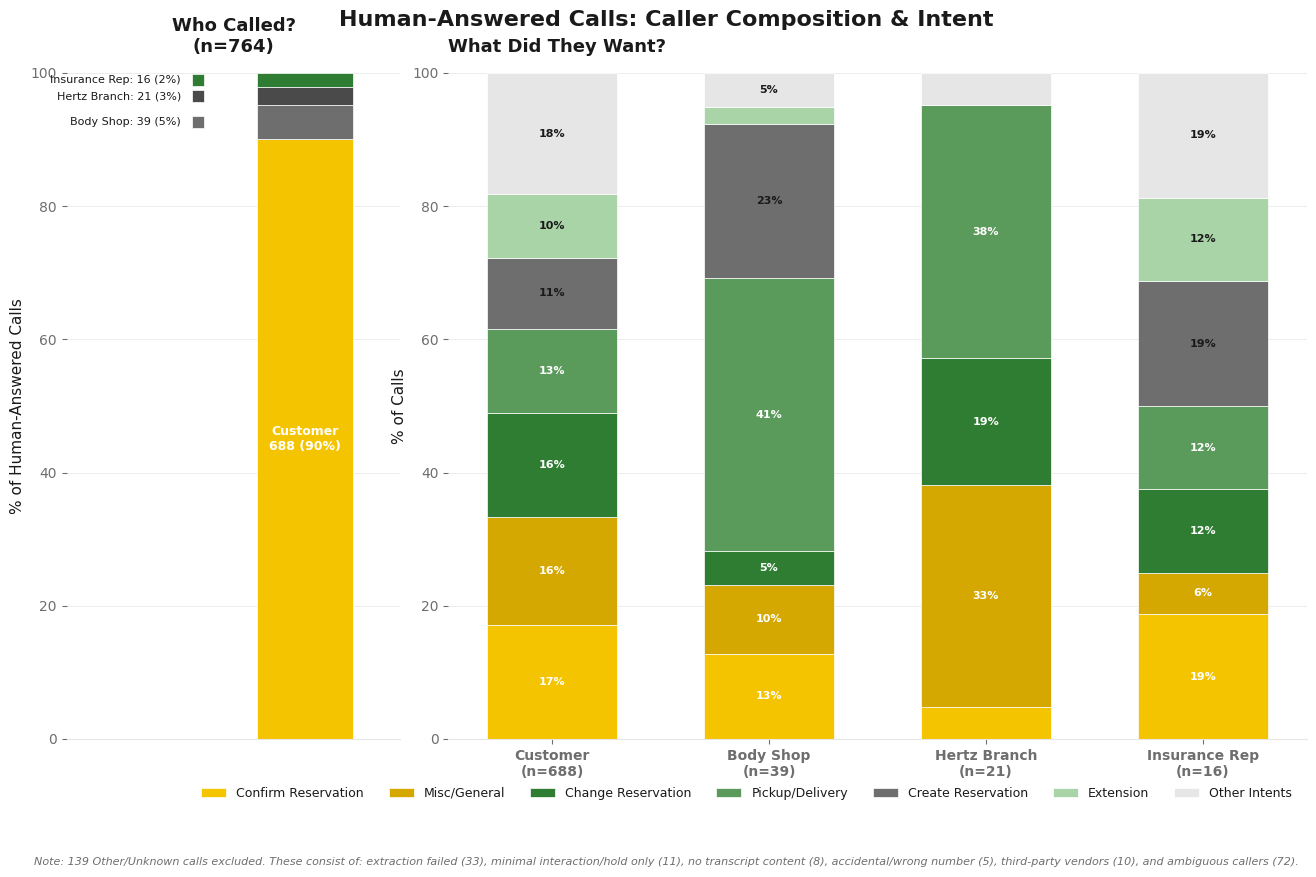


Caller Type Summary (Human-Answered Only, n=764, excluding 139 Other/Unknown):
  Customer: 688 calls (90%) → Top intent: Confirm Reservation
  Body Shop: 39 calls (5%) → Top intent: Pickup/Delivery
  Hertz Branch: 21 calls (3%) → Top intent: Pickup/Delivery
  Insurance Rep: 16 calls (2%) → Top intent: Create Reservation


In [439]:
# ============================================
# 2.1 ANSWERED BY HUMAN: WHO CALLED & INTENT
# LHS: Who Called (100% vertical bar) | RHS: Intent by Caller Type (100% stacked)
# (Excludes Hailey VA calls - human-answered only)
# ============================================

# Filter to human-answered calls only (excludes Hailey VA)
df_answered_human = df[df['call_status_refined'] == 'answered_by_human'].copy()
n_answered = len(df_answered_human)

# Clean caller type labels
caller_type_map = {
    'customer': 'Customer',
    'other': 'Other/Unknown',
    'body_shop': 'Body Shop',
    'hertz_branch': 'Hertz Branch',
    'insurer_rep': 'Insurance Rep'
}
df_answered_human['caller_type_clean'] = df_answered_human['B_identity_routing.caller_type'].map(caller_type_map).fillna('Other/Unknown')

# Get caller type counts - EXCLUDE Other/Unknown from visualization
caller_counts_all = df_answered_human['caller_type_clean'].value_counts()
n_other_unknown = caller_counts_all.get('Other/Unknown', 0)

# Filter to only the caller types we want to show
caller_order = ['Customer', 'Body Shop', 'Hertz Branch', 'Insurance Rep']
caller_counts = caller_counts_all.reindex([c for c in caller_order if c in caller_counts_all.index])
n_shown = caller_counts.sum()

# Colors for each caller type
caller_colors = {
    'Customer': HERTZ_YELLOW,
    'Body Shop': DARK_GRAY,
    'Hertz Branch': '#4A4A4A',
    'Insurance Rep': POSITIVE_GREEN
}

# Filter dataframe to exclude Other/Unknown for the RHS chart
df_answered_human_filtered = df_answered_human[df_answered_human['caller_type_clean'] != 'Other/Unknown'].copy()

# ========== CREATE FIGURE ==========
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[0.28, 0.72], wspace=0.08)

# ========== LEFT: 100% Stacked Vertical Bar - Who Called ==========
ax1 = fig.add_subplot(gs[0])

bar_width = 0.4
bottom = 0
small_segments = []  # Track small segments for external labels

for caller_type in caller_counts.index:
    count = caller_counts[caller_type]
    pct = count / n_shown * 100
    
    bar = ax1.bar(0.3, pct, bottom=bottom, width=bar_width,
                  color=caller_colors.get(caller_type, DARK_GRAY),
                  edgecolor='white', linewidth=0.5)
    
    # Add label inside bar if tall enough, otherwise track for external label
    if pct >= 12:
        ax1.text(0.3, bottom + pct/2, f'{caller_type}\n{count:,} ({pct:.0f}%)', 
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if caller_type not in ['Other/Unknown'] else CHARCOAL)
    else:
        small_segments.append((caller_type, count, pct, bottom + pct/2, caller_colors.get(caller_type, DARK_GRAY)))
    
    bottom += pct

# Add external annotations for small segments - ON THE LEFT SIDE
for caller_type, count, pct, y_pos, color in small_segments:
    # Small colored marker on left
    ax1.plot(-0.15, y_pos, 's', markersize=8, color=color, markeredgecolor='white', markeredgewidth=0.5)
    ax1.text(-0.22, y_pos, f'{caller_type}: {count} ({pct:.0f}%)', 
            fontsize=8, color=CHARCOAL, va='center', ha='right')

ax1.set_ylim(0, 100)
ax1.set_xlim(-0.7, 0.7)
ax1.set_xticks([])
ax1.set_ylabel('% of Human-Answered Calls', fontsize=11)
style_axis(ax1)
ax1.set_title(f'Who Called?\n(n={n_shown:,})', 
              fontsize=13, fontweight='bold', color=CHARCOAL, loc='center', pad=15)

# ========== RIGHT: 100% Stacked Vertical Bars - Intent by Caller Type ==========
ax2 = fig.add_subplot(gs[1])

# Get top intents from filtered data
top_intents = df_answered_human_filtered['C_intent.primary_intent'].value_counts().head(6).index.tolist()

# Clean intent labels - rename "other" to "Misc/General" to avoid confusion
intent_label_map = {
    'other': 'Misc/General',
    'change_reservation': 'Change Reservation',
    'confirm_reservation': 'Confirm Reservation',
    'pickup_delivery_coordination': 'Pickup/Delivery',
    'create_reservation': 'Create Reservation',
    'extension': 'Extension',
    'repair_issue': 'Repair Issue',
    'payment_deposit': 'Payment/Deposit',
    'other_intents': 'Other Intents'
}

# Intent colors - using Yellow, Green, and distinct shades (no gray overload)
intent_colors_list = [
    HERTZ_YELLOW,      # Misc/General (primary)
    '#D4A800',         # Confirm Reservation (darker yellow)
    POSITIVE_GREEN,    # Change Reservation (green)
    '#5A9A5A',         # Pickup/Delivery (lighter green)
    DARK_GRAY,         # Create Reservation (gray)
    '#A8D4A8',         # Extension (pale green)
    LIGHT_GRAY         # Other Intents (light gray)
]

# Create crosstab and normalize to percentages (using filtered data)
intent_by_caller = pd.crosstab(
    df_answered_human_filtered['caller_type_clean'], 
    df_answered_human_filtered['C_intent.primary_intent'].apply(lambda x: x if x in top_intents else 'other_intents'),
    normalize='index'
) * 100

# Reorder columns
col_order = [c for c in top_intents if c in intent_by_caller.columns]
if 'other_intents' in intent_by_caller.columns:
    col_order.append('other_intents')
intent_by_caller = intent_by_caller[col_order]

# Reorder rows
row_order = [r for r in caller_order if r in intent_by_caller.index]
intent_by_caller = intent_by_caller.reindex(row_order)

# Get counts per caller type for x-axis labels
caller_n = {caller: int(caller_counts.get(caller, 0)) for caller in row_order}

# Plot 100% stacked bars for each caller type
x = np.arange(len(intent_by_caller))
bar_width = 0.6

bars_for_legend = []
labels_for_legend = []

for i, intent in enumerate(intent_by_caller.columns):
    bottom_vals = intent_by_caller.iloc[:, :i].sum(axis=1).values if i > 0 else np.zeros(len(intent_by_caller))
    vals = intent_by_caller[intent].values
    
    bars = ax2.bar(x, vals, bar_width, bottom=bottom_vals,
                   color=intent_colors_list[i % len(intent_colors_list)],
                   edgecolor='white', linewidth=0.5)
    
    bars_for_legend.append(bars[0])
    labels_for_legend.append(intent_label_map.get(intent, intent.replace('_', ' ').title()))
    
    # Add percentage labels - show ALL segments >= 5%
    for j, (bar_x, val, bot) in enumerate(zip(x, vals, bottom_vals)):
        if val >= 5:
            # Determine text color based on background
            if i in [0, 1]:  # Yellow shades - white text
                txt_color = 'white'
            elif i in [2, 3]:  # Green shades - white text
                txt_color = 'white'
            elif i == 5:  # Pale green - dark text
                txt_color = CHARCOAL
            else:  # Gray - dark text
                txt_color = CHARCOAL if i >= 4 else 'white'
            
            ax2.text(bar_x, bot + val/2, f'{val:.0f}%', 
                    ha='center', va='center', fontsize=8, fontweight='bold',
                    color=txt_color)

# X-axis labels with sample sizes
x_labels = [f'{caller}\n(n={caller_n[caller]:,})' for caller in intent_by_caller.index]
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, fontsize=10, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_ylabel('% of Calls', fontsize=11)
style_axis(ax2)
ax2.set_title('What Did They Want?', 
              fontsize=13, fontweight='bold', color=CHARCOAL, loc='left', pad=15)

# Add legend below the chart (horizontal)
fig.legend(bars_for_legend, labels_for_legend, 
           loc='lower center', ncol=len(labels_for_legend), 
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.55, 0.08))

# Add footnote about Other/Unknown calls
footnote = (f"Note: {n_other_unknown} Other/Unknown calls excluded. These consist of: "
            f"extraction failed (33), minimal interaction/hold only (11), no transcript content (8), "
            f"accidental/wrong number (5), third-party vendors (10), and ambiguous callers (72).")
fig.text(0.5, 0.02, footnote, fontsize=8, color=DARK_GRAY, ha='center', style='italic', wrap=True)

fig.suptitle('Human-Answered Calls: Caller Composition & Intent', 
             fontsize=16, fontweight='bold', color=CHARCOAL, y=0.97)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16, top=0.90)
plt.show()

# Print summary stats
print(f"\nCaller Type Summary (Human-Answered Only, n={n_shown:,}, excluding {n_other_unknown} Other/Unknown):")
for caller in caller_counts.index:
    count = caller_counts[caller]
    top_intent = df_answered_human_filtered[df_answered_human_filtered['caller_type_clean'] == caller]['C_intent.primary_intent'].value_counts().index[0]
    print(f"  {caller}: {count:,} calls ({count/n_shown*100:.0f}%) → Top intent: {intent_label_map.get(top_intent, top_intent.replace('_', ' '))}")

## 3. Issues & Complaints Analysis

Analyzing issues and complaints from **answered calls only** (calls that reached a human or Hailey VA).

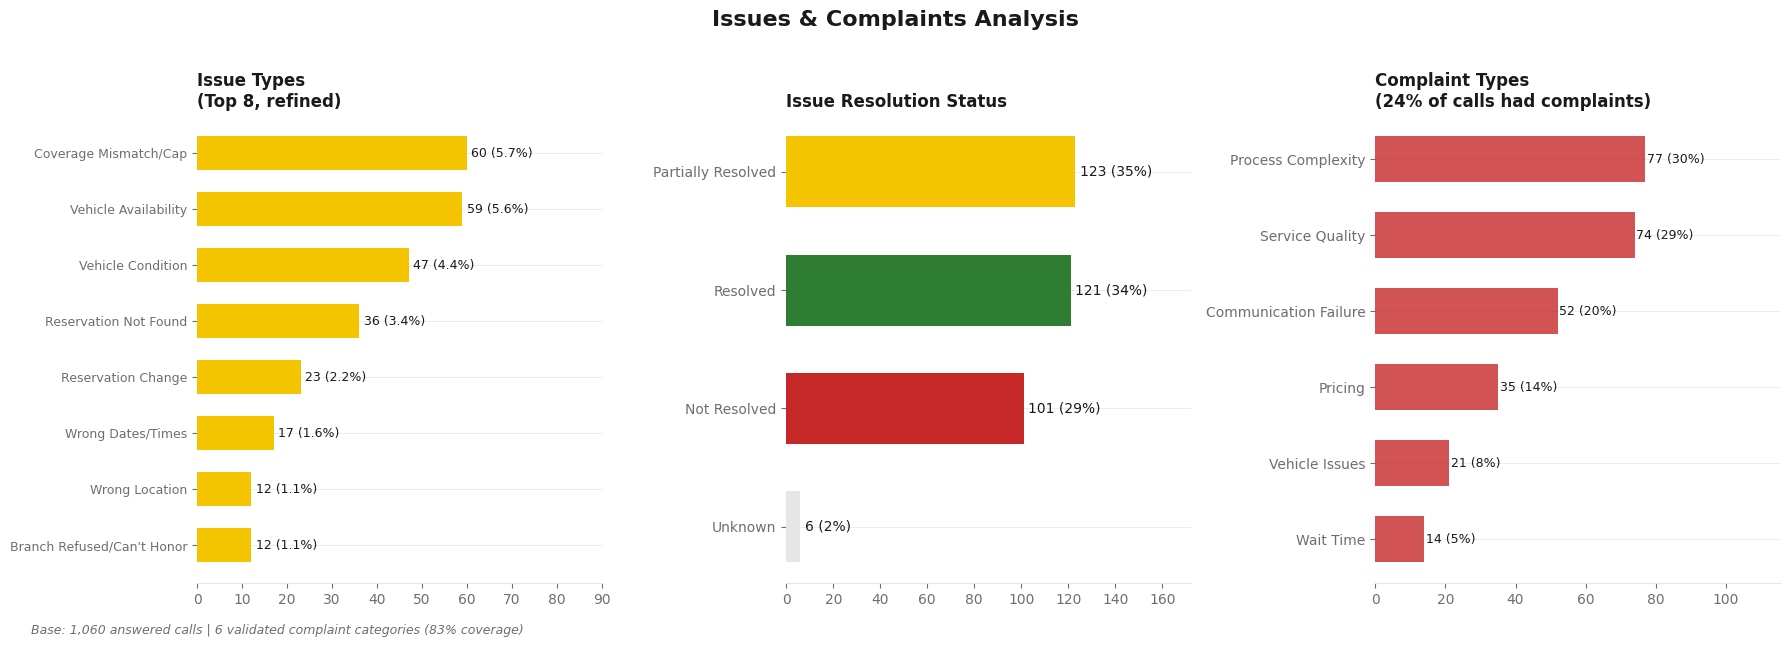


Refined category counts:
  Issues:
    • Vehicle Availability: 59 calls
    • Vehicle Condition: 47 calls
  Complaints (6 validated categories, 83% coverage):
    • Process Complexity: 77 calls
    • Service Quality: 74 calls
    • Communication Failure: 52 calls
    • Pricing: 35 calls
    • Vehicle Issues: 21 calls
    • Wait Time: 14 calls


In [440]:
# ============================================
# 3. ISSUES & COMPLAINTS BREAKDOWN
# ============================================

import re

# Define answered calls (used in this section)
df_answered = df[df['call_status_refined'].isin(['answered_by_human', 'answered_by_va'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ========== LEFT: Issue Types (with refined classification) ==========
ax1 = axes[0]

# Function to classify vehicle issues by content
def classify_vehicle_issue(evidence):
    """Classify vehicle issues based on actual quote content"""
    if pd.isna(evidence) or str(evidence) == 'nan':
        return 'vehicle_availability'  # default if no evidence
    
    text = str(evidence).lower()
    
    # CONDITION keywords
    condition_patterns = [
        r'dirty', r'gash', r'damage', r'worn', r'broken', r'alarm', r'camera',
        r'maintenance', r'repair', r'clean', r'smell', r'stain', r'dent', r'scratch',
        r'tire', r'brake', r'engine', r"won't start", r"doesn't start", r'battery',
        r'fault', r'worse', r'cruise control', r'key', r'lock', r'stolen', r'tow',
        r'charge', r'charging', r'fix', r'exchange it', r'pot', r'stink'
    ]
    
    for pattern in condition_patterns:
        if re.search(pattern, text):
            return 'vehicle_condition'
    
    return 'vehicle_availability'

# Reclassify all issues
def reclassify_issue_type(row):
    issue = row['D_issue_diagnostics.issue_types']
    intent = row['C_intent.primary_intent']
    evidence = row['D_issue_diagnostics.issue_types_evidence']
    
    if pd.isna(issue) or issue in ['none', 'NaN', 'nan']:
        return None
    
    # Split vehicle_unavailable by content
    if 'vehicle_unavailable' in str(issue):
        return classify_vehicle_issue(evidence)
    
    # Reclassify 'other' based on intent
    if issue == 'other':
        if intent == 'repair_issue':
            return 'vehicle_condition'
        elif intent in ['change_reservation', 'extension']:
            return 'reservation_change'
        elif intent == 'pickup_delivery_coordination':
            return 'logistics_issue'
        elif intent == 'payment_deposit':
            return 'payment_issue'
        else:
            return 'misc_other'
    
    # Strip |other from combined issues
    if '|other' in str(issue):
        return issue.replace('|other', '')
    
    # Take first issue from combined
    if '|' in str(issue):
        return issue.split('|')[0]
    
    return issue

df_answered['issue_type_refined'] = df_answered.apply(reclassify_issue_type, axis=1)

# Clean labels for display
issue_label_map = {
    'vehicle_availability': 'Vehicle Availability',
    'vehicle_condition': 'Vehicle Condition',
    'coverage_mismatch_or_cap': 'Coverage Mismatch/Cap',
    'reservation_not_found': 'Reservation Not Found',
    'reservation_change': 'Reservation Change',
    'wrong_dates_times': 'Wrong Dates/Times',
    'branch_refused_or_cant_honor': 'Branch Refused/Can\'t Honor',
    'wrong_location': 'Wrong Location',
    'authorization_missing': 'Authorization Missing',
    'name_or_driver_mismatch': 'Name/Driver Mismatch',
    'logistics_issue': 'Logistics Issue',
    'system_transfer_loop': 'System/Transfer Loop',
    'payment_issue': 'Payment Issue',
    'misc_other': 'Misc Other'
}

issue_types = df_answered['issue_type_refined'].value_counts(dropna=True).head(8)

y_pos = np.arange(len(issue_types))
bars = ax1.barh(y_pos, issue_types.values, color=HERTZ_YELLOW, height=0.6, edgecolor='none')

for bar, val in zip(bars, issue_types.values):
    pct = val / len(df_answered) * 100
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{val} ({pct:.1f}%)', va='center', fontsize=9, color=CHARCOAL)

labels = [issue_label_map.get(str(i), str(i).replace('_', ' ').title()[:25]) for i in issue_types.index]
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlim(0, issue_types.values[0] * 1.5)
ax1.invert_yaxis()
style_axis(ax1)
ax1.set_title('Issue Types\n(Top 8, refined)', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== MIDDLE: Issue Resolution Status ==========
ax2 = axes[1]

resolution = df_answered['D_issue_diagnostics.issue_resolution_status'].value_counts(dropna=True)

res_colors = {
    'resolved': POSITIVE_GREEN,
    'partially_resolved': HERTZ_YELLOW,
    'not_resolved': NEGATIVE_RED,
    'unknown': LIGHT_GRAY,
    'not_applicable': DARK_GRAY
}
colors = [res_colors.get(str(r), DARK_GRAY) for r in resolution.index]

y_pos = np.arange(len(resolution))
bars = ax2.barh(y_pos, resolution.values, color=colors, height=0.6, edgecolor='none')

for bar, val in zip(bars, resolution.values):
    pct = val / resolution.sum() * 100
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
            f'{val:,} ({pct:.0f}%)', va='center', fontsize=10, color=CHARCOAL)

labels = [str(r).replace('_', ' ').title() for r in resolution.index]
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=10)
ax2.set_xlim(0, resolution.values.max() * 1.4)
ax2.invert_yaxis()
style_axis(ax2)
ax2.set_title('Issue Resolution Status', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== RIGHT: Complaint Types (6 validated categories) ==========
ax3 = axes[2]

# Use 6 validated complaint categories (83% coverage)
validated_complaint_categories = [
    'communication_failure', 'process_complexity', 'wait_time',
    'vehicle_issues', 'pricing', 'service_quality'
]

complaint_label_map = {
    'communication_failure': 'Communication Failure',
    'process_complexity': 'Process Complexity',
    'wait_time': 'Wait Time',
    'vehicle_issues': 'Vehicle Issues',
    'pricing': 'Pricing',
    'service_quality': 'Service Quality'
}

# Count calls for each validated category
complaint_counts = {}
for cat in validated_complaint_categories:
    count = df_answered['I_complaints.complaint_types'].str.contains(cat, na=False).sum()
    complaint_counts[cat] = count

# Sort by count
complaint_series = pd.Series(complaint_counts).sort_values(ascending=False)

# Calculate total complaints for rate
complaint_raised = (df_answered['I_complaints.complaint_raised'] == True).sum()
complaint_rate = complaint_raised / len(df_answered) * 100

y_pos = np.arange(len(complaint_series))
bars = ax3.barh(y_pos, complaint_series.values, color=NEGATIVE_RED, height=0.6, edgecolor='none', alpha=0.8)

for bar, val in zip(bars, complaint_series.values):
    pct = val / complaint_raised * 100 if complaint_raised > 0 else 0
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val} ({pct:.0f}%)', va='center', fontsize=9, color=CHARCOAL)

labels = [complaint_label_map.get(c, c.replace('_', ' ').title()) for c in complaint_series.index]
ax3.set_yticks(y_pos)
ax3.set_yticklabels(labels, fontsize=10)
ax3.set_xlim(0, complaint_series.values[0] * 1.5)
ax3.invert_yaxis()

style_axis(ax3)
ax3.set_title(f'Complaint Types\n({complaint_rate:.0f}% of calls had complaints)', 
              fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

fig.suptitle('Issues & Complaints Analysis', fontsize=16, fontweight='bold', color=CHARCOAL, y=1.02)
fig.text(0.02, -0.02, f'Base: {len(df_answered):,} answered calls | 6 validated complaint categories (83% coverage)', 
         fontsize=9, color=DARK_GRAY, ha='left', style='italic')

plt.tight_layout()
plt.show()

# Print summaries
vehicle_avail = (df_answered['issue_type_refined'] == 'vehicle_availability').sum()
vehicle_cond = (df_answered['issue_type_refined'] == 'vehicle_condition').sum()
print(f"\nRefined category counts:")
print(f"  Issues:")
print(f"    • Vehicle Availability: {vehicle_avail} calls")
print(f"    • Vehicle Condition: {vehicle_cond} calls")
print(f"  Complaints (6 validated categories, 83% coverage):")
for cat, count in complaint_series.items():
    print(f"    • {complaint_label_map[cat]}: {count} calls")

/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/988581286.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


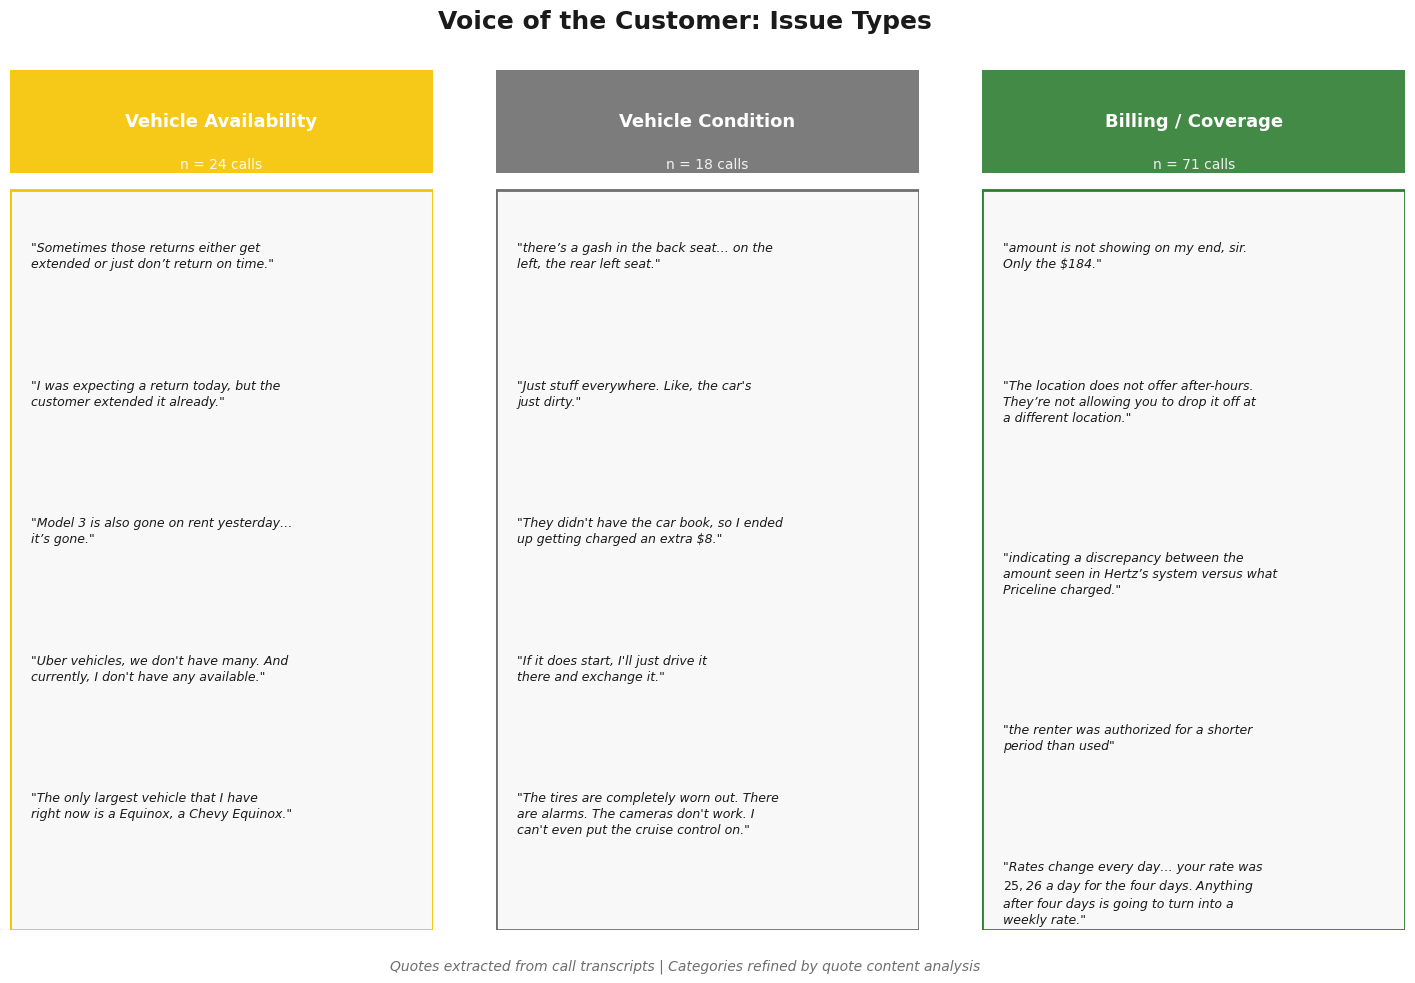


Category counts:
  • Vehicle Availability: 24 calls
  • Vehicle Condition: 18 calls
  • Billing/Coverage: 71 calls


In [441]:
# ============================================
# 3.1 VOICE OF THE CUSTOMER: TOP ISSUE TYPES
# Actual quotes from call transcripts (with refined categorization)
# ============================================

import textwrap
import re

# Get vehicle_unavailable calls and split by content
vehicle_unavail = df_answered[df_answered['D_issue_diagnostics.issue_types'].str.contains('vehicle_unavailable', na=False)].copy()

def classify_vehicle_issue(evidence):
    """Classify vehicle issues based on actual quote content"""
    if pd.isna(evidence) or str(evidence) == 'nan':
        return 'unknown'
    
    text = str(evidence).lower()
    
    # CONDITION keywords
    condition_patterns = [
        r'dirty', r'gash', r'damage', r'worn', r'broken', r'alarm', r'camera',
        r'maintenance', r'repair', r'clean', r'smell', r'stain', r'dent', r'scratch',
        r'tire', r'brake', r'engine', r"won't start", r"doesn't start", r'battery',
        r'fault', r'worse', r'cruise control', r'key', r'lock', r'stolen', r'tow',
        r'charge', r'charging', r'fix', r'exchange it', r'pot', r'stink'
    ]
    
    for pattern in condition_patterns:
        if re.search(pattern, text):
            return 'condition'
    
    # AVAILABILITY keywords  
    availability_patterns = [
        r"don't have", r"do not have", r"sold out", r"out of stock", 
        r"not available", r"no .{0,20} available", r"waiting", r"waitlist", 
        r"return", r"extended", r"rented", r"rent\b", r"gone on rent",
        r"only have", r"only got", r"currently don't", r"right now",
        r"unfortunately", r"completely sold", r"we don't", r"they don't",
        r"no one has", r"not a reservable", r"limited", r"no suv", r"no truck"
    ]
    
    for pattern in availability_patterns:
        if re.search(pattern, text):
            return 'availability'
    
    return 'other'

vehicle_unavail['vehicle_issue_type'] = vehicle_unavail['D_issue_diagnostics.issue_types_evidence'].apply(classify_vehicle_issue)

# Define the 3 categories for visualization
categories = {
    'availability': {
        'label': 'Vehicle Availability',
        'color': HERTZ_YELLOW,
        'data': vehicle_unavail[vehicle_unavail['vehicle_issue_type'] == 'availability']
    },
    'condition': {
        'label': 'Vehicle Condition',
        'color': DARK_GRAY,
        'data': vehicle_unavail[vehicle_unavail['vehicle_issue_type'] == 'condition']
    },
    'billing': {
        'label': 'Billing / Coverage',
        'color': POSITIVE_GREEN,
        'data': df_answered[df_answered['D_issue_diagnostics.issue_types'].str.contains('coverage_mismatch_or_cap', na=False)]
    }
}

def get_clean_quotes(data, evidence_col='D_issue_diagnostics.issue_types_evidence', n_quotes=6):
    """Extract clean quotes from evidence column"""
    quotes = []
    for evidence in data[evidence_col].dropna():
        text = str(evidence).strip()
        if text and text != 'nan' and len(text) > 15 and len(text) < 250:
            text = text.replace('\n', ' ').strip()
            if text not in quotes:
                quotes.append(text)
    return quotes[:n_quotes]

# Create figure
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(1, 3, wspace=0.15)

for idx, (key, cat) in enumerate(categories.items()):
    ax = fig.add_subplot(gs[idx])
    quotes = get_clean_quotes(cat['data'])
    n_calls = len(cat['data'])
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Header box
    header_box = plt.Rectangle((0, 0.88), 1, 0.12, 
                                 facecolor=cat['color'], 
                                 edgecolor='none', alpha=0.9)
    ax.add_patch(header_box)
    ax.text(0.5, 0.94, cat['label'], 
            fontsize=13, fontweight='bold', color='white', 
            ha='center', va='center')
    ax.text(0.5, 0.89, f'n = {n_calls} calls', 
            fontsize=10, color='white', alpha=0.9,
            ha='center', va='center')
    
    # Quote area background
    quote_box = plt.Rectangle((0, 0), 1, 0.86, 
                               facecolor='#F8F8F8', 
                               edgecolor=cat['color'], 
                               linewidth=2)
    ax.add_patch(quote_box)
    
    # Add quotes
    y_pos = 0.80
    for i, quote in enumerate(quotes):
        wrapped = textwrap.fill(f'"{quote}"', width=42)
        lines = wrapped.count('\n') + 1
        
        ax.text(0.05, y_pos, wrapped, 
                fontsize=9, color=CHARCOAL, 
                ha='left', va='top',
                style='italic',
                linespacing=1.3)
        
        y_pos -= (0.12 + (lines - 1) * 0.04)
        
        if y_pos < 0.05:
            break

fig.suptitle('Voice of the Customer: Issue Types', 
             fontsize=18, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, 'Quotes extracted from call transcripts | Categories refined by quote content analysis', 
         fontsize=10, color=DARK_GRAY, ha='center', style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.06)
plt.show()

print(f"\nCategory counts:")
print(f"  • Vehicle Availability: {len(categories['availability']['data'])} calls")
print(f"  • Vehicle Condition: {len(categories['condition']['data'])} calls")
print(f"  • Billing/Coverage: {len(categories['billing']['data'])} calls")

/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/937493380.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


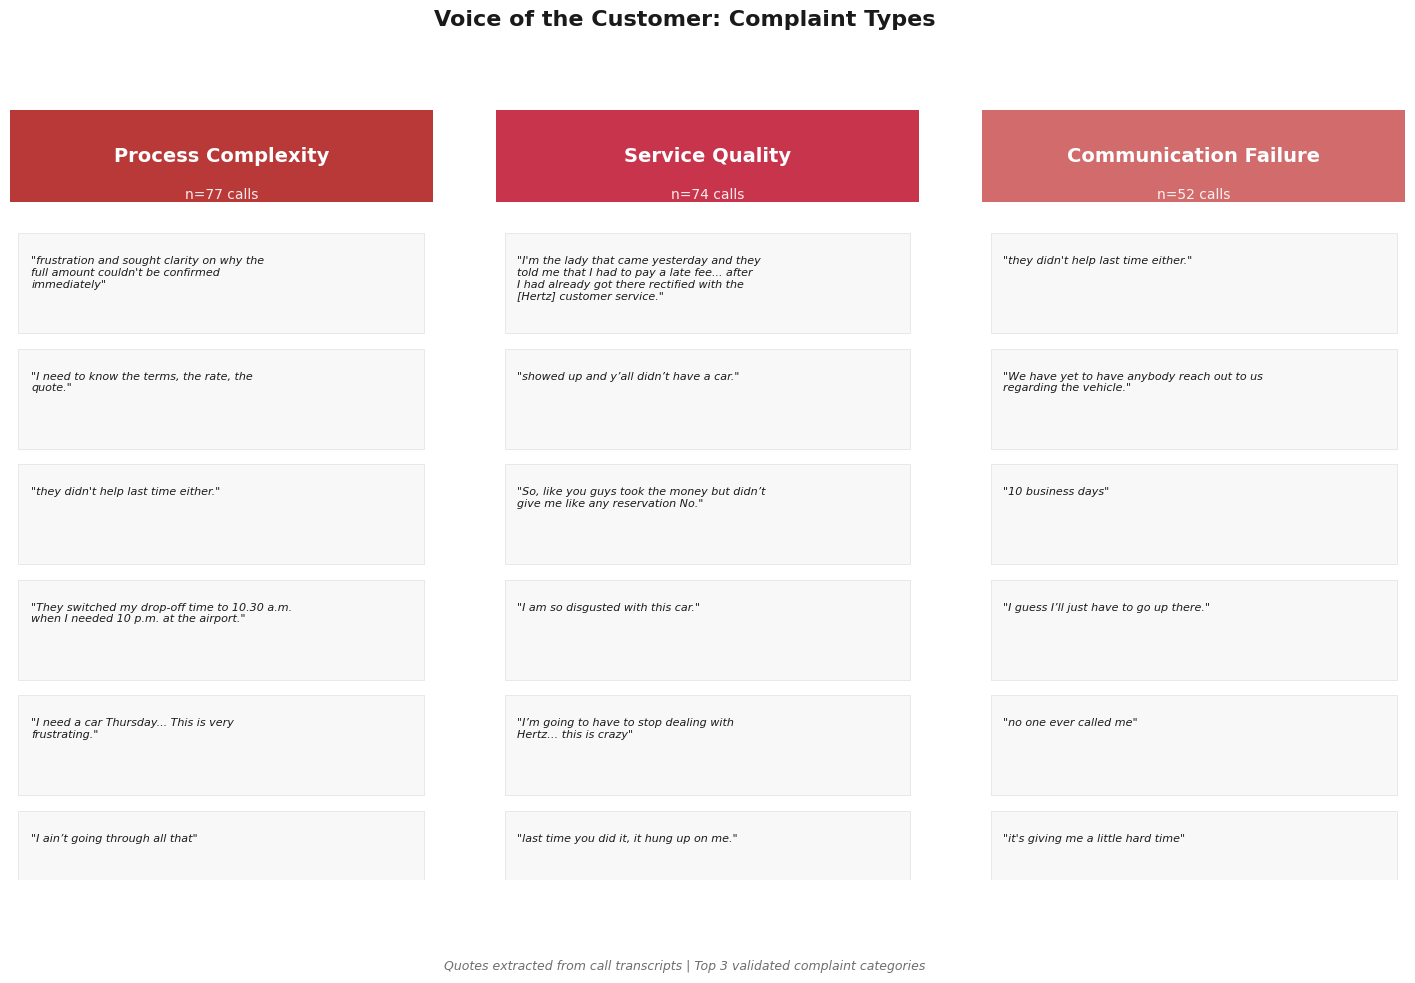


Top 3 complaint categories shown:
  • Process Complexity: 77 calls
  • Service Quality: 74 calls
  • Communication Failure: 52 calls


In [442]:
# ============================================
# 3.2 VOICE OF THE CUSTOMER: TOP COMPLAINT TYPES
# Actual quotes from call transcripts (top 3 from validated categories)
# ============================================

import textwrap

# Get top 3 complaint categories by count from validated set
validated_cats = ['communication_failure', 'process_complexity', 'wait_time',
                  'vehicle_issues', 'pricing', 'service_quality']

cat_counts = {}
for cat in validated_cats:
    cat_counts[cat] = df_answered['I_complaints.complaint_types'].str.contains(cat, na=False).sum()

# Sort and get top 3
top3_cats = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)[:3]

# Define display properties for each category
cat_display = {
    'service_quality': {'label': 'Service Quality', 'color': '#C41E3A'},
    'pricing': {'label': 'Pricing', 'color': '#8B0000'},
    'communication_failure': {'label': 'Communication Failure', 'color': '#CD5C5C'},
    'process_complexity': {'label': 'Process Complexity', 'color': '#B22222'},
    'vehicle_issues': {'label': 'Vehicle Issues', 'color': '#A52A2A'},
    'wait_time': {'label': 'Wait Time', 'color': '#DC143C'}
}

def get_complaint_quotes(complaint_filter, n_quotes=6):
    """Extract clean quotes from complaint evidence"""
    subset = df_answered[df_answered['I_complaints.complaint_types'].str.contains(complaint_filter, na=False)]
    
    quotes = []
    
    # Get from complaint_details_evidence first (usually more specific)
    for evidence in subset['I_complaints.complaint_details_evidence'].dropna():
        text = str(evidence).strip()
        if text and text != 'nan' and len(text) > 15 and len(text) < 200:
            text = text.replace('\n', ' ').strip()
            if text not in quotes:
                quotes.append(text)
    
    # If need more, try complaint_types_evidence
    if len(quotes) < n_quotes:
        for evidence in subset['I_complaints.complaint_types_evidence'].dropna():
            text = str(evidence).strip()
            if text and text != 'nan' and len(text) > 15 and len(text) < 200:
                text = text.replace('\n', ' ').strip()
                if text not in quotes:
                    quotes.append(text)
    
    return quotes[:n_quotes], len(subset)

# Create figure
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(1, 3, wspace=0.15)

for idx, (cat_key, cat_count) in enumerate(top3_cats):
    ax = fig.add_subplot(gs[0, idx])
    
    cat_info = cat_display[cat_key]
    quotes, n_calls = get_complaint_quotes(cat_key)
    
    # Draw header card
    ax.add_patch(plt.Rectangle((0, 0.88), 1, 0.12, transform=ax.transAxes,
                                facecolor=cat_info['color'], edgecolor='none', alpha=0.9))
    ax.text(0.5, 0.94, cat_info['label'], transform=ax.transAxes, fontsize=14, 
            fontweight='bold', color='white', ha='center', va='center')
    ax.text(0.5, 0.89, f'n={n_calls} calls', transform=ax.transAxes, fontsize=10,
            color='white', ha='center', va='center', alpha=0.9)
    
    # Display quotes as cards
    quote_height = 0.13
    start_y = 0.82
    
    for i, quote in enumerate(quotes[:6]):
        y_pos = start_y - (i * (quote_height + 0.02))
        
        # Quote background
        ax.add_patch(plt.Rectangle((0.02, y_pos - quote_height + 0.02), 0.96, quote_height,
                                   transform=ax.transAxes, facecolor='#f8f8f8', 
                                   edgecolor='#e0e0e0', linewidth=0.5))
        
        # Wrap and display quote
        wrapped = textwrap.fill(f'"{quote}"', width=45)
        ax.text(0.05, y_pos - 0.01, wrapped, transform=ax.transAxes, fontsize=8,
                color=CHARCOAL, va='top', ha='left', style='italic',
                linespacing=1.2)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

fig.suptitle('Voice of the Customer: Complaint Types', 
             fontsize=16, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, 'Quotes extracted from call transcripts | Top 3 validated complaint categories',
         fontsize=9, color=DARK_GRAY, ha='center', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\nTop 3 complaint categories shown:")
for cat_key, cat_count in top3_cats:
    print(f"  • {cat_display[cat_key]['label']}: {cat_count} calls")

## 4. Operational Friction: Transfers & Holds

Understanding where calls get transferred and when customers are put on hold helps identify process inefficiencies.

/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/3928869845.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


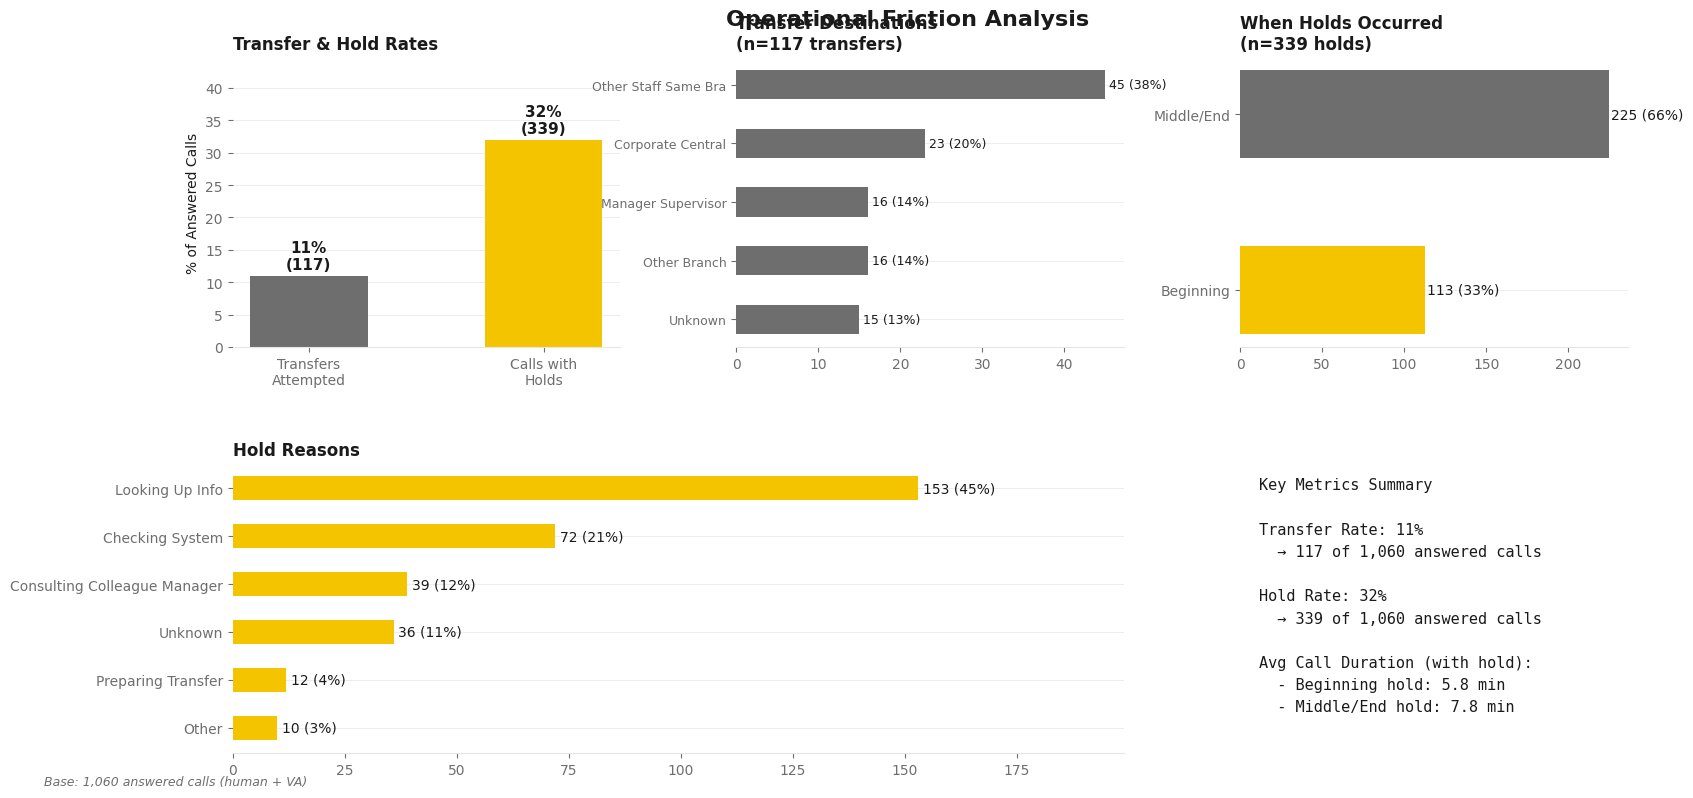

In [443]:
# ============================================
# 4. OPERATIONAL FRICTION: TRANSFERS & HOLDS
# ============================================

fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

n_answered = len(df_answered)

# ========== TOP LEFT: Transfer & Hold Rates ==========
ax1 = fig.add_subplot(gs[0, 0])

transfers = (df_answered['G_transfers_escalations.transfer_attempted'] == True).sum()
holds = (df_answered['J_hold_experience.hold_occurred'] == True).sum()
transfer_rate = transfers / n_answered * 100
hold_rate = holds / n_answered * 100

metrics = ['Transfers\nAttempted', 'Calls with\nHolds']
values = [transfer_rate, hold_rate]
colors = [DARK_GRAY, HERTZ_YELLOW]

bars = ax1.bar(metrics, values, color=colors, width=0.5, edgecolor='none')
for bar, val, count in zip(bars, values, [transfers, holds]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.0f}%\n({count:,})', ha='center', fontsize=11, fontweight='bold', color=CHARCOAL)

ax1.set_ylim(0, max(values) * 1.4)
ax1.set_ylabel('% of Answered Calls', fontsize=10)
style_axis(ax1)
ax1.set_title('Transfer & Hold Rates', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== TOP MIDDLE: Transfer Destinations ==========
ax2 = fig.add_subplot(gs[0, 1])

transfer_dest = df_answered['G_transfers_escalations.transfer_destination'].value_counts(dropna=True)
transfer_dest = transfer_dest[~transfer_dest.index.isin(['NaN', 'nan'])].head(5)

if len(transfer_dest) > 0:
    y_pos = np.arange(len(transfer_dest))
    bars = ax2.barh(y_pos, transfer_dest.values, color=DARK_GRAY, height=0.5, edgecolor='none')
    
    for bar, val in zip(bars, transfer_dest.values):
        pct = val / transfers * 100 if transfers > 0 else 0
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val} ({pct:.0f}%)', va='center', fontsize=9, color=CHARCOAL)
    
    labels = [str(d).replace('_', ' ').title()[:20] for d in transfer_dest.index]
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=9)
    ax2.invert_yaxis()

style_axis(ax2)
ax2.set_title(f'Transfer Destinations\n(n={transfers:,} transfers)', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== TOP RIGHT: Hold Timing ==========
ax3 = fig.add_subplot(gs[0, 2])

hold_timing = df_answered['J_hold_experience.hold_timing'].value_counts(dropna=True)

timing_colors = {'beginning': HERTZ_YELLOW, 'middle_end': DARK_GRAY}
colors = [timing_colors.get(str(t), LIGHT_GRAY) for t in hold_timing.index]

if len(hold_timing) > 0:
    y_pos = np.arange(len(hold_timing))
    bars = ax3.barh(y_pos, hold_timing.values, color=colors, height=0.5, edgecolor='none')
    
    for bar, val in zip(bars, hold_timing.values):
        pct = val / holds * 100 if holds > 0 else 0
        ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{val} ({pct:.0f}%)', va='center', fontsize=10, color=CHARCOAL)
    
    labels = [str(t).replace('_', '/').title() for t in hold_timing.index]
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(labels, fontsize=10)
    ax3.invert_yaxis()

style_axis(ax3)
ax3.set_title(f'When Holds Occurred\n(n={holds:,} holds)', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== BOTTOM LEFT: Hold Reasons ==========
ax4 = fig.add_subplot(gs[1, 0:2])

hold_df = df_answered[df_answered['J_hold_experience.hold_occurred'] == True]
hold_reasons = hold_df['J_hold_experience.hold_reason'].value_counts(dropna=True).head(6)

if len(hold_reasons) > 0:
    y_pos = np.arange(len(hold_reasons))
    bars = ax4.barh(y_pos, hold_reasons.values, color=HERTZ_YELLOW, height=0.5, edgecolor='none')
    
    for bar, val in zip(bars, hold_reasons.values):
        pct = val / holds * 100 if holds > 0 else 0
        ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{val} ({pct:.0f}%)', va='center', fontsize=10, color=CHARCOAL)
    
    labels = [str(r).replace('_', ' ').title()[:35] for r in hold_reasons.index]
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(labels, fontsize=10)
    ax4.set_xlim(0, hold_reasons.values[0] * 1.3)
    ax4.invert_yaxis()

style_axis(ax4)
ax4.set_title('Hold Reasons', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== BOTTOM RIGHT: Key Metrics Summary ==========
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

# Calculate average durations by hold timing
hold_beginning = hold_df[hold_df['J_hold_experience.hold_timing'] == 'beginning']
hold_middle = hold_df[hold_df['J_hold_experience.hold_timing'] == 'middle_end']

avg_duration_beginning = hold_beginning['call_duration_sec'].mean() if len(hold_beginning) > 0 else 0
avg_duration_middle = hold_middle['call_duration_sec'].mean() if len(hold_middle) > 0 else 0

summary_text = f"""Key Metrics Summary

Transfer Rate: {transfer_rate:.0f}%
  → {transfers:,} of {n_answered:,} answered calls

Hold Rate: {hold_rate:.0f}%
  → {holds:,} of {n_answered:,} answered calls

Avg Call Duration (with hold):
  - Beginning hold: {avg_duration_beginning/60:.1f} min
  - Middle/End hold: {avg_duration_middle/60:.1f} min
"""

ax5.text(0.05, 0.95, summary_text, fontsize=11, color=CHARCOAL, va='top', 
         family='monospace', linespacing=1.6, transform=ax5.transAxes)

fig.suptitle('Operational Friction Analysis', fontsize=16, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.02, 0.01, f'Base: {n_answered:,} answered calls (human + VA)', 
         fontsize=9, color=DARK_GRAY, ha='left', style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.05)
plt.show()

---

## 5. Deep Dive: Stuck in Call Tree Analysis

**Why This Matters:** 68% of all inbound calls (2,670) get stuck in the IVR system without reaching a human or completing self-service. Understanding *where* and *why* customers drop off can inform IVR optimization.

**Analysis Approach:**
1. **Call Journey Categorization** - What happened in each call?
2. **Loop Detection** - Are customers stuck in repeating menus?
3. **Customer Voice Analysis** - Can we detect frustration/confusion?
4. **IVR Path Analysis** - Which menus do customers reach before dropping?
5. **Duration Patterns** - How long do customers wait before giving up?

In [444]:
# ============================================
# 5.1 STUCK CALL ANALYSIS - DATA PREPARATION
# ============================================

import re
from collections import Counter

# Filter to stuck calls
df_stuck = df[df['call_status_refined'] == 'stuck_in_call_tree'].copy()
n_stuck = len(df_stuck)

print(f"Analyzing {n_stuck:,} stuck-in-call-tree calls")
print("="*60)

# Function to analyze transcript patterns
def analyze_stuck_transcript(transcript):
    """Extract detailed patterns from a stuck call transcript"""
    if pd.isna(transcript):
        return {col: None for col in ['journey_category', 'loop_count', 'max_menu_depth', 
                                       'customer_speech', 'frustration_detected', 'menus_reached']}
    
    t = str(transcript).lower()
    
    # --- Journey Category ---
    # Check for self-service completion
    got_info_goodbye = ('goodbye' in t or 'thank you for calling' in t.split('|')[-1].lower()) and \
                       any(x in t for x in ['address', 'hours', 'receipt', 'after-hours'])
    
    # Check for transfer/hold attempt
    transfer_attempt = 'your call is being transferred' in t or 'transferring' in t
    hold_attempt = 'please hold' in t and 'next available' in t
    
    # Check for loop (menu repeated)
    menu_phrases = re.findall(r'(press \d|to repeat|previous menu)', t)
    phrase_counts = Counter(menu_phrases)
    is_looping = any(c >= 2 for c in phrase_counts.values())
    
    # Check for invalid responses
    invalid_response = 'not a valid response' in t or 'please select an option' in t
    
    # Determine journey category
    if got_info_goodbye:
        journey = 'self_service_complete'
    elif transfer_attempt or hold_attempt:
        journey = 'almost_there'
    elif is_looping and invalid_response:
        journey = 'loop_with_errors'
    elif is_looping:
        journey = 'loop_victim'
    elif 'press' not in t:
        journey = 'quick_dropoff'
    else:
        journey = 'menu_explorer'
    
    # --- Loop Detection ---
    # Count how many times the same menu repeats
    all_menus = re.findall(r'(to book|to extend|for roadside|for assistance|to make.*reservation)', t)
    loop_count = max(Counter(all_menus).values()) if all_menus else 0
    
    # --- Menu Depth ---
    # Track which level of menu they reached
    menu_levels = {
        'main_menu': any(x in t for x in ['press 1', 'press 2', 'press 3', 'press 4', 'press 5']),
        'sub_menu': any(x in t for x in ['to better assist', 'please choose one of the following']),
        'deep_menu': any(x in t for x in ['rental record number', 'confirmation number', 'deposit', 'receipt'])
    }
    max_depth = sum(menu_levels.values())
    
    # --- Customer Speech Detection ---
    # Look for non-IVR utterances
    customer_patterns = r'\b(hello\??|hi|yes|no|what\??|why|damn|shit|come on|i need|i want|anyone|help|operator|um|uh|okay|i don\'t)\b'
    customer_matches = re.findall(customer_patterns, t)
    has_customer_speech = len(customer_matches) > 0
    
    # Frustration detection
    frustration_patterns = r'\b(damn|shit|fuck|come on|what the|are you kidding|hello\?|anyone there|frustrated)\b'
    frustration_detected = bool(re.search(frustration_patterns, t))
    
    # --- Menus Reached ---
    menus = []
    if 'reservation' in t: menus.append('reservation')
    if 'rental in progress' in t or 'extend' in t: menus.append('rental_in_progress')
    if 'roadside' in t: menus.append('roadside')
    if 'receipt' in t or 'invoice' in t: menus.append('receipt')
    if 'lost and found' in t: menus.append('lost_found')
    if 'insurance' in t: menus.append('insurance')
    
    return {
        'journey_category': journey,
        'loop_count': loop_count,
        'max_menu_depth': max_depth,
        'customer_speech': has_customer_speech,
        'frustration_detected': frustration_detected,
        'menus_reached': '|'.join(menus) if menus else 'main_only'
    }

# Apply analysis to all stuck calls
analysis_results = df_stuck['Transcript'].apply(analyze_stuck_transcript)
analysis_df = pd.DataFrame(analysis_results.tolist())

# Merge back
df_stuck = pd.concat([df_stuck.reset_index(drop=True), analysis_df], axis=1)

# Summary
print("\nJourney Category Distribution:")
print(df_stuck['journey_category'].value_counts())

Analyzing 2,670 stuck-in-call-tree calls

Journey Category Distribution:
journey_category
loop_victim              1180
loop_with_errors          538
menu_explorer             344
quick_dropoff             342
self_service_complete     249
almost_there               17
Name: count, dtype: int64


/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/2289603038.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


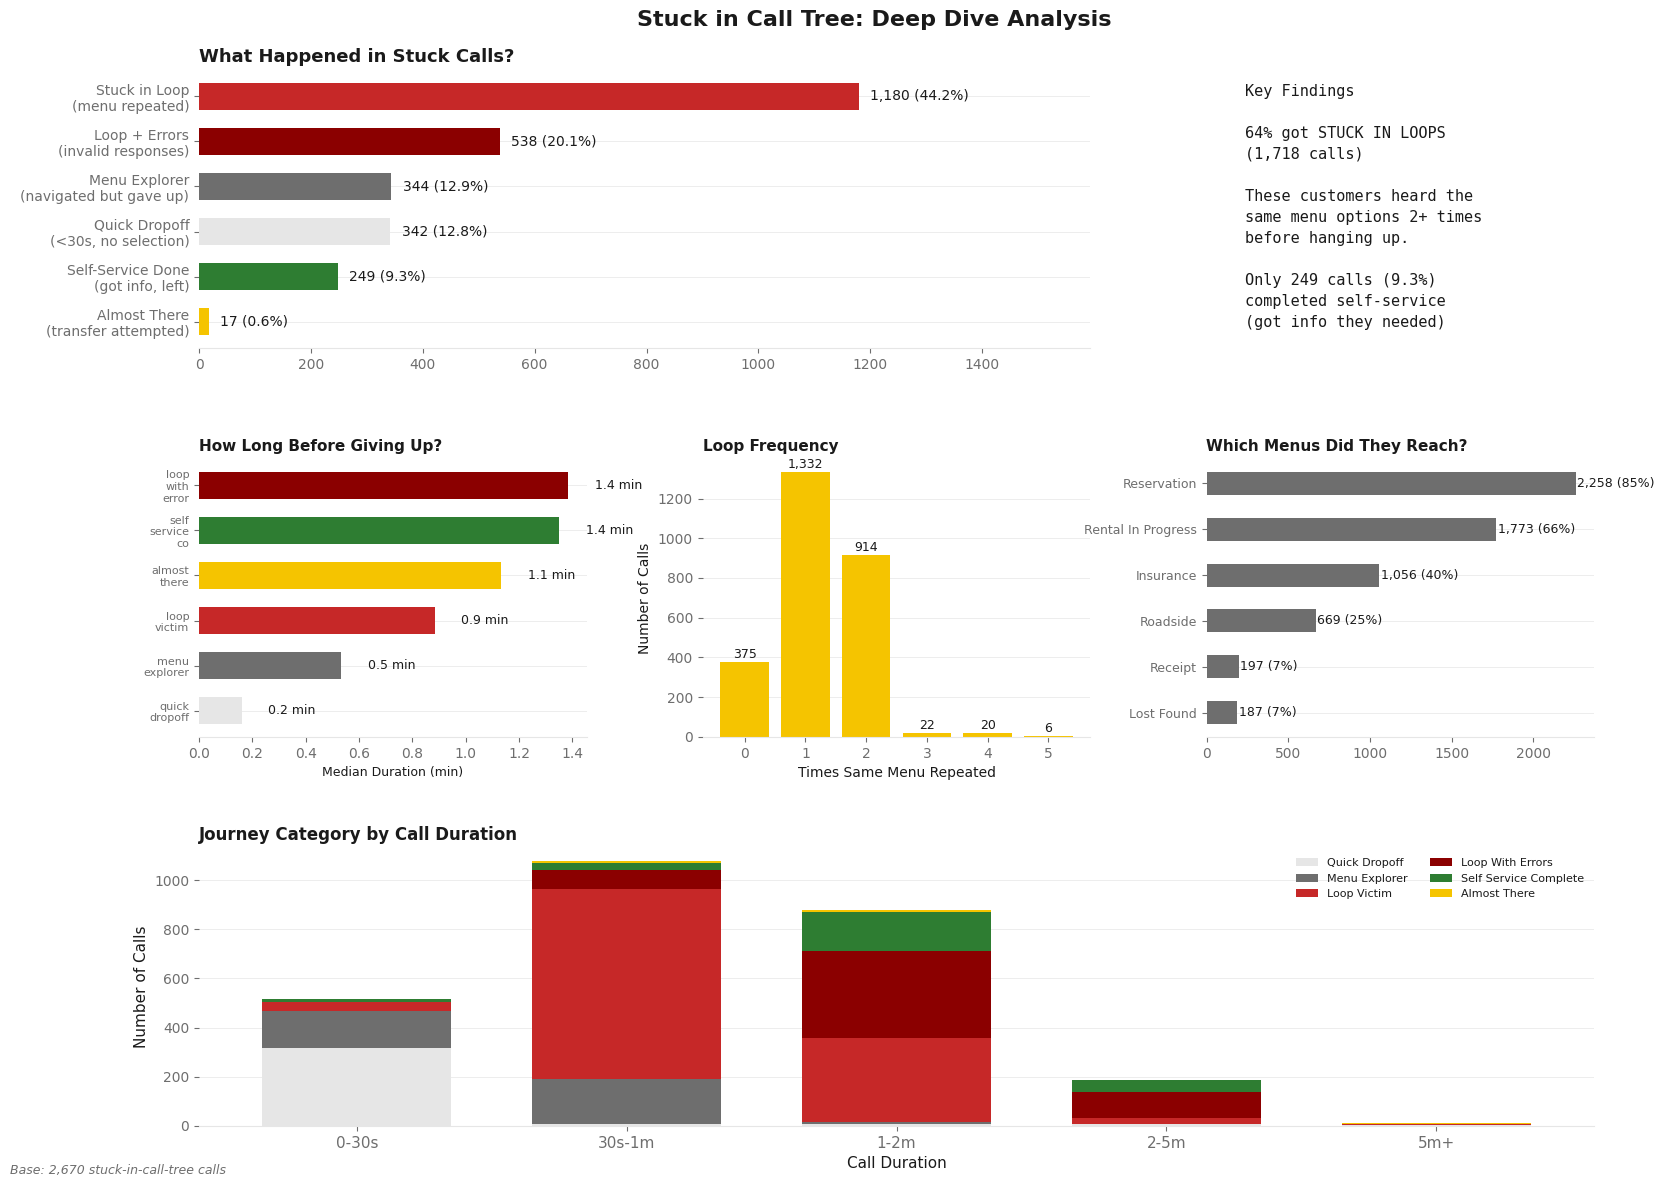

In [445]:
# ============================================
# 5.2 STUCK CALL JOURNEY VISUALIZATION
# ============================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# ========== TOP LEFT: Journey Category Breakdown ==========
ax1 = fig.add_subplot(gs[0, 0:2])

journey_counts = df_stuck['journey_category'].value_counts()
journey_labels = {
    'loop_victim': 'Stuck in Loop\n(menu repeated)',
    'menu_explorer': 'Menu Explorer\n(navigated but gave up)',
    'loop_with_errors': 'Loop + Errors\n(invalid responses)',
    'self_service_complete': 'Self-Service Done\n(got info, left)',
    'quick_dropoff': 'Quick Dropoff\n(<30s, no selection)',
    'almost_there': 'Almost There\n(transfer attempted)'
}

colors_journey = {
    'loop_victim': NEGATIVE_RED,
    'menu_explorer': DARK_GRAY,
    'loop_with_errors': '#8B0000',  # Dark red
    'self_service_complete': POSITIVE_GREEN,
    'quick_dropoff': LIGHT_GRAY,
    'almost_there': HERTZ_YELLOW
}

y_pos = np.arange(len(journey_counts))
bars = ax1.barh(y_pos, journey_counts.values, 
                color=[colors_journey.get(j, DARK_GRAY) for j in journey_counts.index],
                height=0.6, edgecolor='none')

for bar, val in zip(bars, journey_counts.values):
    pct = val / n_stuck * 100
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=10, color=CHARCOAL)

labels = [journey_labels.get(j, j) for j in journey_counts.index]
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlim(0, journey_counts.values[0] * 1.35)
ax1.invert_yaxis()
style_axis(ax1)
ax1.set_title('What Happened in Stuck Calls?', fontsize=13, fontweight='bold', color=CHARCOAL, loc='left')

# ========== TOP RIGHT: Key Insight Box ==========
ax_insight = fig.add_subplot(gs[0, 2])
ax_insight.axis('off')

loop_total = journey_counts.get('loop_victim', 0) + journey_counts.get('loop_with_errors', 0)
loop_pct = loop_total / n_stuck * 100
self_service = journey_counts.get('self_service_complete', 0)

insight_text = f"""Key Findings

{loop_pct:.0f}% got STUCK IN LOOPS
({loop_total:,} calls)

These customers heard the
same menu options 2+ times
before hanging up.

Only {self_service:,} calls ({self_service/n_stuck*100:.1f}%)
completed self-service
(got info they needed)
"""
ax_insight.text(0.1, 0.95, insight_text, fontsize=11, color=CHARCOAL, va='top', 
                linespacing=1.5, family='monospace', transform=ax_insight.transAxes)

# ========== MIDDLE LEFT: Duration by Journey Category ==========
ax2 = fig.add_subplot(gs[1, 0])

# Calculate median duration by journey
duration_by_journey = df_stuck.groupby('journey_category')['call_duration_sec'].median().sort_values(ascending=True)

y_pos = np.arange(len(duration_by_journey))
bars = ax2.barh(y_pos, duration_by_journey.values / 60,  # Convert to minutes
                color=[colors_journey.get(j, DARK_GRAY) for j in duration_by_journey.index],
                height=0.6, edgecolor='none')

for bar, val in zip(bars, duration_by_journey.values):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val/60:.1f} min', va='center', fontsize=9, color=CHARCOAL)

short_labels = [j.replace('_', '\n')[:15] for j in duration_by_journey.index]
ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_labels, fontsize=8)
ax2.set_xlabel('Median Duration (min)', fontsize=9)
style_axis(ax2)
ax2.set_title('How Long Before Giving Up?', fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== MIDDLE CENTER: Loop Count Distribution ==========
ax3 = fig.add_subplot(gs[1, 1])

loop_counts = df_stuck['loop_count'].value_counts().sort_index()
loop_counts = loop_counts[loop_counts.index <= 5]  # Cap at 5 for visualization

bars = ax3.bar(loop_counts.index, loop_counts.values, color=HERTZ_YELLOW, edgecolor='none')
for bar, val in zip(bars, loop_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'{val:,}', ha='center', fontsize=9, color=CHARCOAL)

ax3.set_xlabel('Times Same Menu Repeated', fontsize=10)
ax3.set_ylabel('Number of Calls', fontsize=10)
ax3.set_xticks(loop_counts.index)
style_axis(ax3)
ax3.set_title('Loop Frequency', fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== MIDDLE RIGHT: Menus Reached ==========
ax4 = fig.add_subplot(gs[1, 2])

# Parse menus reached
all_menus = []
for menus in df_stuck['menus_reached'].dropna():
    all_menus.extend(menus.split('|'))
menu_counts = pd.Series(Counter(all_menus)).sort_values(ascending=True)
menu_counts = menu_counts[menu_counts.index != 'main_only']

if len(menu_counts) > 0:
    y_pos = np.arange(len(menu_counts))
    bars = ax4.barh(y_pos, menu_counts.values, color=DARK_GRAY, height=0.5, edgecolor='none')
    
    for bar, val in zip(bars, menu_counts.values):
        pct = val / n_stuck * 100
        ax4.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                f'{val:,} ({pct:.0f}%)', va='center', fontsize=9, color=CHARCOAL)
    
    labels = [m.replace('_', ' ').title() for m in menu_counts.index]
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(labels, fontsize=9)

style_axis(ax4)
ax4.set_title('Which Menus Did They Reach?', fontsize=11, fontweight='bold', color=CHARCOAL, loc='left')

# ========== BOTTOM: Duration Distribution by Category ==========
ax5 = fig.add_subplot(gs[2, :])

# Create duration buckets
duration_buckets = pd.cut(df_stuck['call_duration_sec'], 
                          bins=[0, 30, 60, 120, 300, 9999],
                          labels=['0-30s', '30s-1m', '1-2m', '2-5m', '5m+'])
df_stuck['duration_bucket'] = duration_buckets

# Cross-tab journey vs duration
crosstab = pd.crosstab(df_stuck['duration_bucket'], df_stuck['journey_category'])
crosstab = crosstab[['quick_dropoff', 'menu_explorer', 'loop_victim', 'loop_with_errors', 'self_service_complete', 'almost_there']]

# Stacked bar
x = np.arange(len(crosstab))
width = 0.7
bottom = np.zeros(len(crosstab))

for col in crosstab.columns:
    vals = crosstab[col].values
    ax5.bar(x, vals, width, bottom=bottom, label=col.replace('_', ' ').title(),
            color=colors_journey.get(col, DARK_GRAY), edgecolor='none')
    bottom += vals

ax5.set_xticks(x)
ax5.set_xticklabels(crosstab.index, fontsize=11)
ax5.set_xlabel('Call Duration', fontsize=11)
ax5.set_ylabel('Number of Calls', fontsize=11)
ax5.legend(loc='upper right', fontsize=8, frameon=False, ncol=2)
style_axis(ax5)
ax5.set_title('Journey Category by Call Duration', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

fig.suptitle('Stuck in Call Tree: Deep Dive Analysis', fontsize=16, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.02, 0.01, f'Base: {n_stuck:,} stuck-in-call-tree calls', 
         fontsize=9, color=DARK_GRAY, ha='left', style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.05)
plt.show()

Analyzing 2,855 calls (stuck + not_answered)


/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_91901/502022304.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


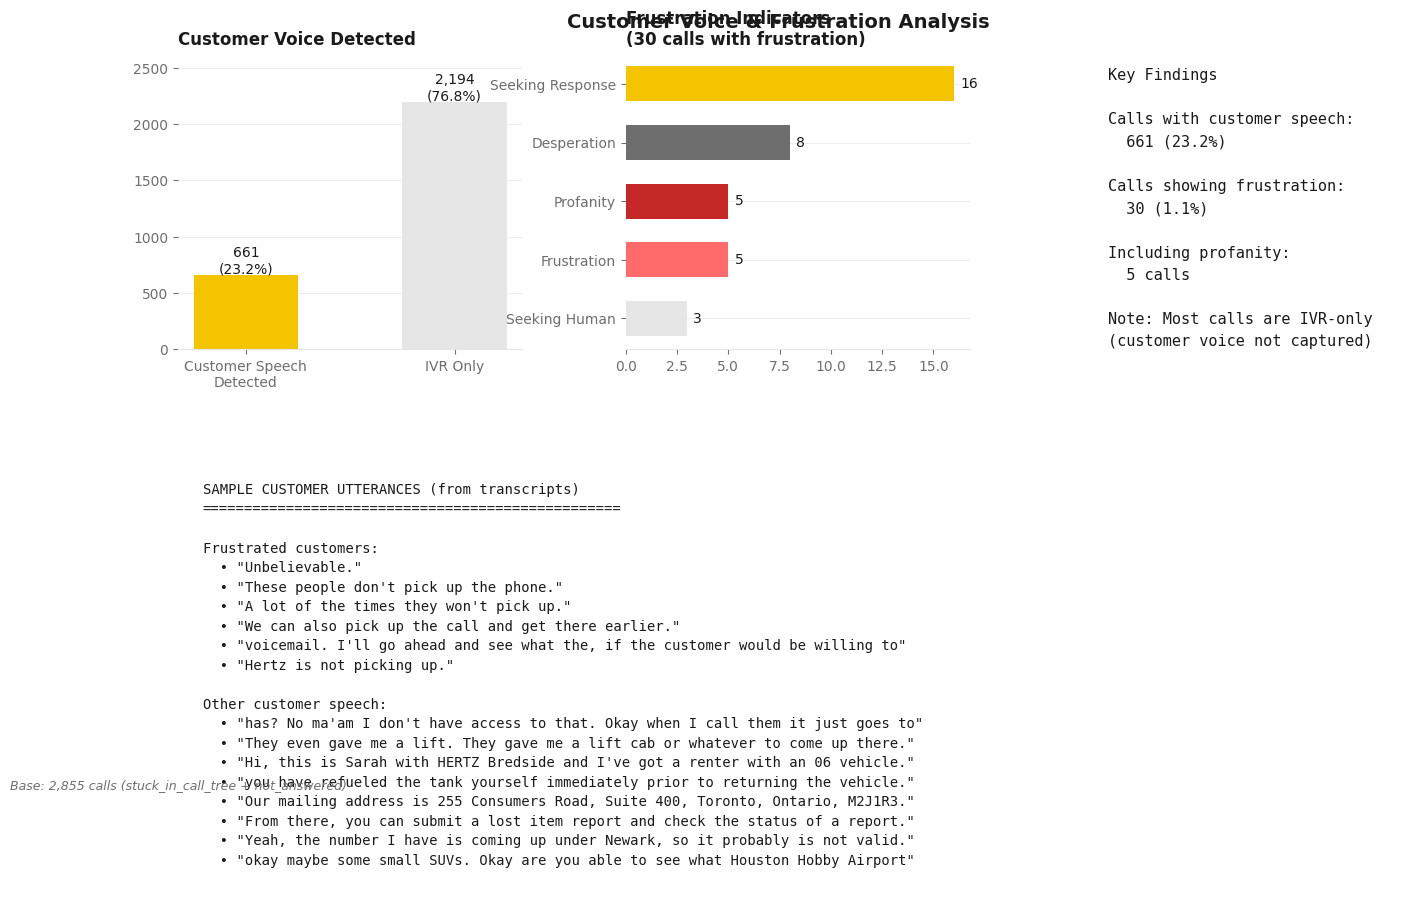

In [446]:
# ============================================
# 5.3 CUSTOMER VOICE & FRUSTRATION ANALYSIS
# (Including stuck_in_call_tree AND not_answered)
# ============================================

# Expand to include not_answered calls
df_ivr_calls = df[df['call_status_refined'].isin(['stuck_in_call_tree', 'not_answered'])].copy()
n_ivr = len(df_ivr_calls)

print(f"Analyzing {n_ivr:,} calls (stuck + not_answered)")

# Function to extract CUSTOMER speech only (exclude IVR text)
def extract_customer_speech(transcript):
    """Extract segments that appear to be customer speech, not IVR"""
    if pd.isna(transcript):
        return []
    
    # IVR phrases to exclude
    ivr_patterns = r'(thank you for calling|press \d|please (hold|wait|listen|choose|select|call back)|your call|for (assistance|roadside|reservation|emergency|our address|faster service)|to (book|extend|make|repeat|speak|get|better)|if you|rental (record|receipt|in progress)|option|menu|website|app\.?|hertz\.(com|app)|www\.|hours of operation|recorded or monitored|quality assurance|important message|telemarketing|this is not|we are calling from|closed (saturday|sunday)|emergency (medical|roadside)|dial 911|monday through friday|a\.m\.|p\.m\.)'
    
    segments = str(transcript).split(' | ')
    customer_segments = []
    
    for seg in segments:
        # Remove timestamp
        clean = re.sub(r'\[\d+\.?\d* - \d+\.?\d*\]\s*', '', seg).strip()
        
        # Skip if clearly IVR
        if re.search(ivr_patterns, clean.lower()):
            continue
        
        # Skip very short (numbers/extensions) or very long (definitely IVR)
        if len(clean) < 4 or len(clean) > 80:
            continue
        
        # Skip if starts with typical IVR patterns
        if re.match(r'^(For |To |If |Your |This |Please |Or |When |The |After|Receipt)', clean):
            continue
            
        customer_segments.append(clean)
    
    return customer_segments

# Function to detect frustration in customer speech
def detect_frustration(transcript):
    """Detect frustration patterns in actual customer speech segments"""
    if pd.isna(transcript):
        return {'has_frustration': False, 'patterns': [], 'examples': []}
    
    customer_speech = extract_customer_speech(transcript)
    full_text = ' '.join(customer_speech).lower()
    
    # Only look in customer speech, not full transcript
    frustration_patterns = [
        (r'\bfuck(ing|ed)?\b', 'profanity'),
        (r'\bshit\b', 'profanity'),
        (r'\bdamn(it)?\b', 'profanity'),
        (r'\bgoddamn\b', 'profanity'),
        (r'\bcrap\b', 'profanity'),
        (r'\bass(hole)?\b', 'profanity'),
        (r'are you (serious|kidding)', 'disbelief'),
        (r'(oh )?come on\b', 'frustration'),
        (r'what the', 'frustration'),
        (r'oh my (god|gosh)', 'frustration'),
        (r'this is (ridiculous|stupid|crazy)', 'frustration'),
        (r'\bunbelievable\b', 'frustration'),
        (r'\bseriously\?', 'disbelief'),
        (r'pick up', 'desperation'),
        (r'(not|never|nobody|no one).*(answer|pick)', 'desperation'),
        (r'hello\?+', 'seeking_response'),
        (r'(anyone|anybody|someone) there', 'seeking_response'),
        (r'(need|want) (a |to )?(talk|speak|person|human|agent)', 'seeking_human'),
    ]
    
    found_patterns = []
    examples = []
    
    for pattern, category in frustration_patterns:
        if re.search(pattern, full_text):
            found_patterns.append(category)
            # Find the actual segment
            for seg in customer_speech:
                if re.search(pattern, seg.lower()):
                    examples.append(seg)
    
    return {
        'has_frustration': len(found_patterns) > 0,
        'patterns': list(set(found_patterns)),
        'examples': examples[:3]
    }

# Analyze all calls
frustration_results = df_ivr_calls['Transcript'].apply(detect_frustration)
df_ivr_calls['frustration_info'] = frustration_results
df_ivr_calls['has_frustration'] = frustration_results.apply(lambda x: x['has_frustration'])
df_ivr_calls['frustration_patterns'] = frustration_results.apply(lambda x: x['patterns'])
df_ivr_calls['frustration_examples'] = frustration_results.apply(lambda x: x['examples'])

# Also extract all customer speech
df_ivr_calls['customer_speech'] = df_ivr_calls['Transcript'].apply(extract_customer_speech)
df_ivr_calls['has_customer_speech'] = df_ivr_calls['customer_speech'].apply(lambda x: len(x) > 0)

# ========== VISUALIZATION ==========
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

# ========== TOP LEFT: Customer Speech Detection ==========
ax1 = fig.add_subplot(gs[0, 0])

speech_with = df_ivr_calls['has_customer_speech'].sum()
speech_without = n_ivr - speech_with

bars = ax1.bar(['Customer Speech\nDetected', 'IVR Only'], 
               [speech_with, speech_without],
               color=[HERTZ_YELLOW, LIGHT_GRAY], width=0.5, edgecolor='none')

for bar, val in zip(bars, [speech_with, speech_without]):
    pct = val / n_ivr * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, color=CHARCOAL)

ax1.set_ylim(0, max(speech_with, speech_without) * 1.2)
style_axis(ax1)
ax1.set_title('Customer Voice Detected', fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== TOP MIDDLE: Frustration Categories ==========
ax2 = fig.add_subplot(gs[0, 1])

# Count frustration patterns
all_patterns = []
for patterns in df_ivr_calls['frustration_patterns']:
    all_patterns.extend(patterns)
pattern_counts = pd.Series(Counter(all_patterns)).sort_values(ascending=True)

if len(pattern_counts) > 0:
    y_pos = np.arange(len(pattern_counts))
    colors_frust = {'profanity': NEGATIVE_RED, 'frustration': '#FF6B6B', 'disbelief': '#FFA07A', 
                    'desperation': DARK_GRAY, 'seeking_response': HERTZ_YELLOW, 'seeking_human': LIGHT_GRAY}
    bars = ax2.barh(y_pos, pattern_counts.values, 
                    color=[colors_frust.get(p, DARK_GRAY) for p in pattern_counts.index],
                    height=0.6, edgecolor='none')
    
    for bar, val in zip(bars, pattern_counts.values):
        ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{val}', va='center', fontsize=10, color=CHARCOAL)
    
    labels = [p.replace('_', ' ').title() for p in pattern_counts.index]
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=10)

style_axis(ax2)
ax2.set_title(f'Frustration Indicators\n({df_ivr_calls["has_frustration"].sum()} calls with frustration)', 
              fontsize=12, fontweight='bold', color=CHARCOAL, loc='left')

# ========== TOP RIGHT: Key Stats ==========
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')

frustrated_calls = df_ivr_calls['has_frustration'].sum()
profanity_calls = sum(1 for p in df_ivr_calls['frustration_patterns'] if 'profanity' in p)

stats_text = f"""Key Findings

Calls with customer speech:
  {speech_with:,} ({speech_with/n_ivr*100:.1f}%)

Calls showing frustration:
  {frustrated_calls:,} ({frustrated_calls/n_ivr*100:.1f}%)

Including profanity:
  {profanity_calls} calls

Note: Most calls are IVR-only
(customer voice not captured)
"""
ax3.text(0.1, 0.95, stats_text, fontsize=11, color=CHARCOAL, va='top', 
         linespacing=1.6, family='monospace', transform=ax3.transAxes)

# ========== BOTTOM: Sample Customer Utterances ==========
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')

# Collect interesting customer speech examples
all_speech = []
for speech_list in df_ivr_calls['customer_speech']:
    all_speech.extend(speech_list)

# Filter for interesting ones
interesting_speech = [s for s in all_speech if len(s) > 10 and not s.replace('.','').isdigit()]
unique_speech = list(set(interesting_speech))

# Get frustration examples
frustration_examples = []
for examples in df_ivr_calls['frustration_examples']:
    frustration_examples.extend(examples)
unique_frustration = list(set(frustration_examples))[:10]

utterance_text = "SAMPLE CUSTOMER UTTERANCES (from transcripts)\n" + "="*50 + "\n\n"

if unique_frustration:
    utterance_text += "Frustrated customers:\n"
    for u in unique_frustration[:6]:
        utterance_text += f'  • "{u}"\n'
    utterance_text += "\n"

utterance_text += "Other customer speech:\n"
for u in sorted(unique_speech, key=len, reverse=True)[:8]:
    if u not in unique_frustration:
        utterance_text += f'  • "{u}"\n'

ax4.text(0.02, 0.95, utterance_text, fontsize=10, color=CHARCOAL, va='top', 
         linespacing=1.5, family='monospace', transform=ax4.transAxes)

fig.suptitle('Customer Voice & Frustration Analysis', fontsize=14, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.02, 0.01, f'Base: {n_ivr:,} calls (stuck_in_call_tree + not_answered)', 
         fontsize=9, color=DARK_GRAY, ha='left', style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.04)
plt.show()

In [447]:
# ============================================
# 5.4 STUCK + NOT ANSWERED - KEY FINDINGS SUMMARY
# ============================================

print("="*70)
print("IVR DROPOUT ANALYSIS: KEY FINDINGS")
print("(Stuck in Call Tree + Not Answered)")
print("="*70)

# Use df_stuck for journey analysis (stuck only) and df_ivr_calls for voice analysis (stuck + not answered)
loop_total = df_stuck[df_stuck['journey_category'].isin(['loop_victim', 'loop_with_errors'])].shape[0]
quick_drop = df_stuck[df_stuck['journey_category'] == 'quick_dropoff'].shape[0]
self_service = df_stuck[df_stuck['journey_category'] == 'self_service_complete'].shape[0]
almost_there = df_stuck[df_stuck['journey_category'] == 'almost_there'].shape[0]

median_duration = df_stuck['call_duration_sec'].median()
long_calls = (df_stuck['call_duration_sec'] > 120).sum()

# Voice/frustration stats from combined analysis
n_with_speech = df_ivr_calls['has_customer_speech'].sum()
n_frustrated = df_ivr_calls['has_frustration'].sum()
n_profanity = sum(1 for p in df_ivr_calls['frustration_patterns'] if 'profanity' in p)

print(f"""
VOLUME BREAKDOWN:
  • Stuck in Call Tree: {n_stuck:,} calls (68% of all inbound)
  • Not Answered: {len(df_ivr_calls) - n_stuck:,} calls
  • TOTAL IVR Dropouts: {n_ivr:,} calls

STUCK CALL JOURNEY (n={n_stuck:,}):
  • {loop_total:,} ({loop_total/n_stuck*100:.0f}%) got STUCK IN LOOPS
  • {quick_drop:,} ({quick_drop/n_stuck*100:.0f}%) hung up IMMEDIATELY (<30s)
  • {self_service:,} ({self_service/n_stuck*100:.0f}%) completed SELF-SERVICE
  • {almost_there:,} ({almost_there/n_stuck*100:.0f}%) were ALMOST THERE (transfer attempted)

DURATION:
  • Median time before giving up: {median_duration/60:.1f} minutes
  • {long_calls:,} calls ({long_calls/n_stuck*100:.0f}%) lasted >2 minutes

CUSTOMER VOICE ANALYSIS (n={n_ivr:,}):
  • {n_with_speech:,} calls ({n_with_speech/n_ivr*100:.1f}%) had detectable customer speech
  • {n_frustrated:,} calls showed frustration signals
  • {n_profanity} calls contained profanity (explicit frustration)

MENUS WHERE CUSTOMERS GET STUCK:
""")

# Top menus from earlier analysis
menu_summary = pd.Series(Counter(all_menus)).sort_values(ascending=False).head(5)
for menu, count in menu_summary.items():
    if menu != 'main_only':
        print(f"  • {menu.replace('_', ' ').title()}: {count:,} calls ({count/n_stuck*100:.0f}%)")

print(f"""
{'='*70}
RECOMMENDATIONS:
{'='*70}

1. FIX MENU LOOPS
   → {loop_total:,} customers heard same menu 2+ times before giving up
   → Add escape route after 2 loops (e.g., "Press 0 for operator")

2. ADD CALLBACK OPTION  
   → Offer callback after 60 seconds in IVR
   → {long_calls:,} customers waited >2 min with no resolution

3. SIMPLIFY "TALK TO HUMAN" PATH
   → Customers asking "can I speak to someone?" end up stuck
   → Make "Press 0 for agent" available at every menu level

4. MONITOR SELF-SERVICE SUCCESS
   → Only {self_service:,} ({self_service/n_stuck*100:.0f}%) completed self-service
   → Most wanted human help but couldn't reach one

5. REVIEW IVR DESIGN
   → "Rental in progress" and "Reservation" menus are dropout hotspots
   → Consider reducing menu depth for common requests
""")

print("="*70)

IVR DROPOUT ANALYSIS: KEY FINDINGS
(Stuck in Call Tree + Not Answered)

VOLUME BREAKDOWN:
  • Stuck in Call Tree: 2,670 calls (68% of all inbound)
  • Not Answered: 185 calls
  • TOTAL IVR Dropouts: 2,855 calls

STUCK CALL JOURNEY (n=2,670):
  • 1,718 (64%) got STUCK IN LOOPS
  • 342 (13%) hung up IMMEDIATELY (<30s)
  • 249 (9%) completed SELF-SERVICE
  • 17 (1%) were ALMOST THERE (transfer attempted)

DURATION:
  • Median time before giving up: 0.9 minutes
  • 200 calls (7%) lasted >2 minutes

CUSTOMER VOICE ANALYSIS (n=2,855):
  • 661 calls (23.2%) had detectable customer speech
  • 30 calls showed frustration signals
  • 5 calls contained profanity (explicit frustration)

MENUS WHERE CUSTOMERS GET STUCK:

  • Reservation: 2,258 calls (85%)
  • Rental In Progress: 1,773 calls (66%)
  • Insurance: 1,056 calls (40%)
  • Roadside: 669 calls (25%)

RECOMMENDATIONS:

1. FIX MENU LOOPS
   → 1,718 customers heard same menu 2+ times before giving up
   → Add escape route after 2 loops (e.g.,